# Ellipticals paper plots

1. CMD diagram </br>
2. IFU </br>
3. velocity dispersion and corrected velocity dispersion </br>
4. stellar mass density and mass profile
5. M* vs. Mr (within r90 for both) split by spirals cmd class
6. Mvir vs Mr for ellipticals and spirals
7. mvir vs Mstar for ellipticals
8. nsa and pipe3d comparison of mstar
9. agn bpt and mvir vs mstar
10. stellar metallicity, stellar age, sfr histograms

## imports and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
# import marvin
import pyneb as pn
from marvin.tools.image import Image
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit

[INFO]: No release version set. Setting default to DR17
[WARNING]: /Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/marvin/__init__.py:400: MarvinUserWarning: path /Users/nityaravi/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/dapall-v3_1_1-3.1.0.fits cannot be found. Setting dapall to None.
  warnings.warn('path {0} cannot be found. Setting dapall to None.'



In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v6.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90,count_M_star_0p1_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/final/'

In [6]:
ellipticals = master_table[master_table['Mvir'] > 0]
ellipticals = ellipticals[ellipticals['sphd_M_star'] > 0]
spirals = master_table[master_table['v_max'] > 0]
spirals = spirals[spirals['M90_disk'] > 0]
spirals = spirals[spirals['alpha'] <= 99]
spirals = spirals[spirals['v_max_err']/spirals['v_max'] <= 2]
v90 = spirals['v_max'] * spirals['R90_kpc'] / (spirals['r_turn']**spirals['alpha'] + spirals['R90_kpc']**spirals['alpha'])**(1/spirals['alpha'])
all_mass_spirals = spirals[np.logical_and(v90 > 10, v90 < 1000)]
spirals = all_mass_spirals[all_mass_spirals['M90_disk']>9]

In [7]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [8]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [9]:
p3d = Table.read(DATA_FOLDER + 'SDSS17Pipe3D_v3_1_1.fits', format='fits')
p3d[:5]

name,plate,ifudsgn,plateifu,mangaid,objra,objdec,log_SFR_Ha,FoV,Re_kpc,e_log_Mass,e_log_SFR_Ha,log_Mass,log_SFR_ssp,log_NII_Ha_cen,e_log_NII_Ha_cen,log_OIII_Hb_cen,e_log_OIII_Hb_cen,log_SII_Ha_cen,e_log_SII_Ha_cen,log_OII_Hb_cen,e_log_OII_Hb_cen,EW_Ha_cen,e_EW_Ha_cen,ZH_LW_Re_fit,e_ZH_LW_Re_fit,alpha_ZH_LW_Re_fit,e_alpha_ZH_LW_Re_fit,ZH_MW_Re_fit,e_ZH_MW_Re_fit,alpha_ZH_MW_Re_fit,e_alpha_ZH_MW_Re_fit,Age_LW_Re_fit,e_Age_LW_Re_fit,alpha_Age_LW_Re_fit,e_alpha_Age_LW_Re_fit,Age_MW_Re_fit,e_Age_MW_Re_fit,alpha_Age_MW_Re_fit,e_alpha_Age_MW_Re_fit,Re_arc,DL,DA,PA,ellip,log_Mass_gas,vel_sigma_Re,e_vel_sigma_Re,log_SFR_SF,log_SFR_D_C,OH_O3N2_cen,e_OH_O3N2_cen,OH_N2_cen,e_OH_N2_cen,OH_ONS_cen,e_OH_ONS_cen,OH_R23_cen,e_OH_R23_cen,OH_pyqz_cen,e_OH_pyqz_cen,OH_t2_cen,e_OH_t2_cen,OH_M08_cen,e_OH_M08_cen,OH_T04_cen,e_OH_T04_cen,OH_dop_cen,e_OH_dop_cen,OH_O3N2_EPM09_cen,e_OH_O3N2_EPM09_cen,log_OI_Ha_cen,e_log_OI_Ha_cen,Ha_Hb_cen,e_Ha_Hb_cen,log_NII_Ha_Re,e_log_NII_Ha_Re,log_OIII_Hb_Re,e_log_OIII_Hb_Re,log_SII_Ha_Re,e_log_SII_Ha_Re,log_OII_Hb_Re,e_log_OII_Hb_Re,log_OI_Ha_Re,e_log_OI_Ha_Re,EW_Ha_Re,e_EW_Ha_Re,Ha_Hb_Re,e_Ha_Hb_Re,log_NII_Ha_ALL,e_log_NII_Ha_ALL,log_OIII_Hb_ALL,e_log_OIII_Hb_ALL,log_SII_Ha_ALL,e_log_SII_Ha_ALL,log_OII_Hb_ALL,e_log_OII_Hb_ALL,log_OI_Ha_ALL,e_log_OI_Ha_ALL,EW_Ha_ALL,e_EW_Ha_ALL,Ha_Hb_ALL,Sigma_Mass_cen,e_Sigma_Mass_cen,Sigma_Mass_Re,e_Sigma_Mass_Re,Sigma_Mass_ALL,e_Sigma_Mass_ALL,T30,ZH_T30,ZH_Re_T30,a_ZH_T30,T40,ZH_T40,ZH_Re_T40,a_ZH_T40,T50,ZH_T50,ZH_Re_T50,a_ZH_T50,T60,ZH_T60,ZH_Re_T60,a_ZH_T60,T70,ZH_T70,ZH_Re_T70,a_ZH_T70,T80,ZH_T80,ZH_Re_T80,a_ZH_T80,T90,ZH_T90,ZH_Re_T90,a_ZH_T90,T95,ZH_T95,ZH_Re_T95,a_ZH_T95,T99,ZH_T99,ZH_Re_T99,a_ZH_T99,log_Mass_gas_Av_gas_OH,log_Mass_gas_Av_ssp_OH,vel_ssp_2,e_vel_ssp_2,vel_Ha_2,e_vel_Ha_2,vel_ssp_1,e_vel_ssp_1,vel_Ha_1,e_vel_Ha_1,log_SFR_ssp_100Myr,log_SFR_ssp_10Myr,vel_disp_Ha_cen,vel_disp_ssp_cen,vel_disp_Ha_1Re,vel_disp_ssp_1Re,log_Mass_in_Re,ML_int,ML_avg,F_Ha_cen,e_F_Ha_cen,R50_kpc_V,e_R50_kpc_V,R50_kpc_Mass,e_R50_kpc_Mass,log_Mass_corr_in_R50_V,e_log_Mass_corr_in_R50_V,log_Mass_gas_Av_gas_log_log,Av_gas_Re,e_Av_gas_Re,Av_ssp_Re,e_Av_ssp_Re,Lambda_Re,e_Lambda_Re,nsa_redshift,nsa_mstar,nsa_inclination,flux_[OII]3726.03_Re_fit,e_flux_[OII]3726.03_Re_fit,flux_[OII]3726.03_alpha_fit,e_flux_[OII]3726.03_alpha_fit,flux_[OII]3728.82_Re_fit,e_flux_[OII]3728.82_Re_fit,flux_[OII]3728.82_alpha_fit,e_flux_[OII]3728.82_alpha_fit,flux_HI3734.37_Re_fit,e_flux_HI3734.37_Re_fit,flux_HI3734.37_alpha_fit,e_flux_HI3734.37_alpha_fit,flux_HI3797.9_Re_fit,e_flux_HI3797.9_Re_fit,flux_HI3797.9_alpha_fit,e_flux_HI3797.9_alpha_fit,flux_HeI3888.65_Re_fit,e_flux_HeI3888.65_Re_fit,flux_HeI3888.65_alpha_fit,e_flux_HeI3888.65_alpha_fit,flux_HI3889.05_Re_fit,e_flux_HI3889.05_Re_fit,flux_HI3889.05_alpha_fit,e_flux_HI3889.05_alpha_fit,flux_HeI3964.73_Re_fit,e_flux_HeI3964.73_Re_fit,flux_HeI3964.73_alpha_fit,e_flux_HeI3964.73_alpha_fit,flux_[NeIII]3967.46_Re_fit,e_flux_[NeIII]3967.46_Re_fit,flux_[NeIII]3967.46_alpha_fit,e_flux_[NeIII]3967.46_alpha_fit,flux_CaII3968.47_Re_fit,e_flux_CaII3968.47_Re_fit,flux_CaII3968.47_alpha_fit,e_flux_CaII3968.47_alpha_fit,flux_Hepsilon3970.07_Re_fit,e_flux_Hepsilon3970.07_Re_fit,flux_Hepsilon3970.07_alpha_fit,e_flux_Hepsilon3970.07_alpha_fit,flux_Hdelta4101.77_Re_fit,e_flux_Hdelta4101.77_Re_fit,flux_Hdelta4101.77_alpha_fit,e_flux_Hdelta4101.77_alpha_fit,flux_Hgamma4340.49_Re_fit,e_flux_Hgamma4340.49_Re_fit,flux_Hgamma4340.49_alpha_fit,e_flux_Hgamma4340.49_alpha_fit,flux_Hbeta4861.36_Re_fit,e_flux_Hbeta4861.36_Re_fit,flux_Hbeta4861.36_alpha_fit,e_flux_Hbeta4861.36_alpha_fit,flux_[OIII]4958.91_Re_fit,e_flux_[OIII]4958.91_Re_fit,flux_[OIII]4958.91_alpha_fit,e_flux_[OIII]4958.91_alpha_fit,flux_[OIII]5006.84_Re_fit,e_flux_[OIII]5006.84_Re_fit,flux_[OIII]5006.84_alpha_fit,e_flux_[OIII]5006.84_alpha_fit,flux_HeI5015.68_Re_fit,e_flux_HeI5015.68_Re_fit,flux_HeI5015.68_alpha_fit,e_flux_HeI5015.68_alpha_fit,flux_[NI]5197.9_Re_fit,e_flux_[NI]5197.9_Re_fit,flux_[NI]5197.9_alpha_fit

In [10]:
p3d_dict = {}
for i in range(len(p3d)):
    p3d_dict[p3d[i]['plateifu']] = i

In [11]:
ellipticals['Age_LW_Re_fit'] = -99.
ellipticals['Age_MW_Re_fit'] = -99.
ellipticals['ZH_LW_Re_fit'] = -99.
ellipticals['ZH_MW_Re_fit'] = -99.

for i in range(len(ellipticals)):

    try:

        i_p = p3d_dict[ellipticals[i]['plateifu']]

        ellipticals['Age_LW_Re_fit'][i] = p3d[i_p]['Age_LW_Re_fit']
        ellipticals['Age_MW_Re_fit'][i] = p3d[i_p]['Age_MW_Re_fit']
        ellipticals['ZH_LW_Re_fit'][i] = p3d[i_p]['ZH_LW_Re_fit']
        ellipticals['ZH_MW_Re_fit'][i] = p3d[i_p]['ZH_MW_Re_fit']
    
    except:
        print(ellipticals[i]['plateifu'])

[WARNING]: /Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value



10496-3704
10837-12702
11980-3703
12678-3702
12683-1902
9514-6102


In [12]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

## plots

### set up test gal

In [165]:
gal_ID = '8319-1902'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, '8319-1902', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8319-1902', ['star_sigma', 'flux'])

idx = master_table_dict[gal_ID]
sMass = pipe3d_maps['sMass_density']
sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]

### cmd diagram (ellipticals)

In [236]:
cmd_color_dict = {1.0: 'b',
            2.0: 'g',
            3.0:'r',
            -99: 'k',
           -1: 'k'}
cmd_marker_dict = {1.0: '+',
            2.0: '*',
            3.0:'.',
            -99: '.',
           -1: '.'}
cmd_fc_dict = {1.0: None,
            2.0: None,
            3.0:'none',
            -99: None,
           -1: None}

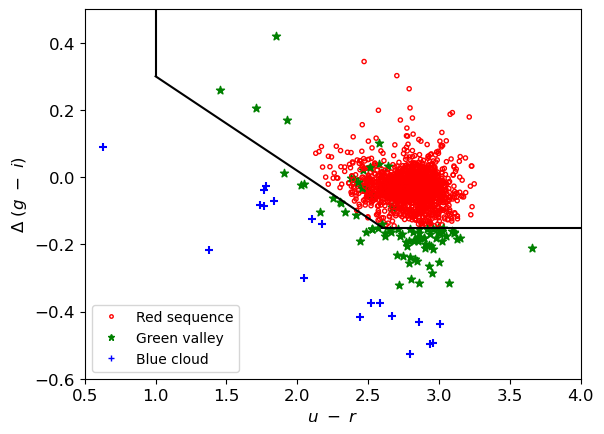

In [239]:
for i in range(len(ellipticals)):
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    plt.scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker=cmd_marker_dict[ellipticals[i]['CMD_class']], 
                color=cmd_color_dict[ellipticals[i]['CMD_class']], 
               facecolor=cmd_fc_dict[ellipticals[i]['CMD_class']],
               )


plt.xlim(0.5,4)
plt.ylim(-0.6,0.5)
plt.xlabel(r'$u\ -\ r$', fontsize=12)
plt.ylabel(r'$\Delta\ (g\ -\ i)$', fontsize=12)
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='.', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='*', color='w', label='Green valley',
                          markeredgecolor='g', markerfacecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markerfacecolor='b', markersize=5)]
plt.tick_params( axis='both', labelsize=12)


plt.legend(handles=legend_elements, loc='lower left')
plt.savefig(plot_dir + 'CMD.png', bbox_inches='tight')

### IFU

### vel disp

In [52]:
star_sigma = dap_maps['star_sigma']
star_sigma_mask = dap_maps['star_sigma_mask']
star_sigma_correction = dap_maps['star_sigma_corr']

mstar_sigma = ma.array(star_sigma, mask=star_sigma_mask)
mstar_sigma_correction = ma.array(star_sigma_correction, mask=star_sigma_mask)
mstar_sigma_corr = np.sqrt(mstar_sigma**2 - mstar_sigma_correction**2)

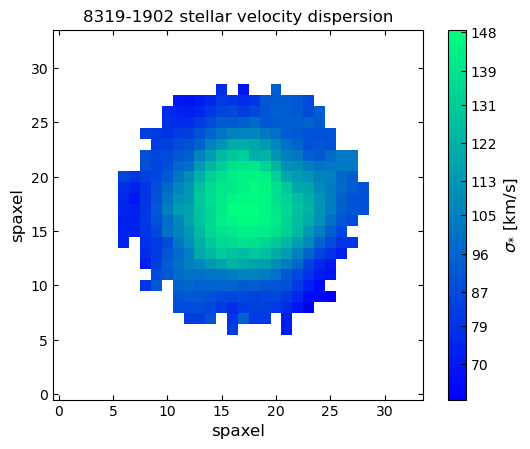

In [63]:
fig, ax = plt.subplots()

cbar_ticks = np.linspace(ma.min(mstar_sigma), ma.max(mstar_sigma), 11, dtype='int')
ax.set_title(gal_ID + ' stellar velocity dispersion', fontsize=12)

vel_im = ax.imshow( mstar_sigma, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=ma.min(mstar_sigma), 
                    vmax=ma.max(mstar_sigma))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=10)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=12) 

ax.tick_params( axis='both', direction='in', labelsize=10)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=12)
ax.set_ylabel('spaxel', fontsize=12)
ax.set_title('8319-1902 stellar velocity dispersion')


plt.savefig(plot_dir + gal_ID + '_stel_sigma.png', bbox_inches='tight', pad_inches=0)

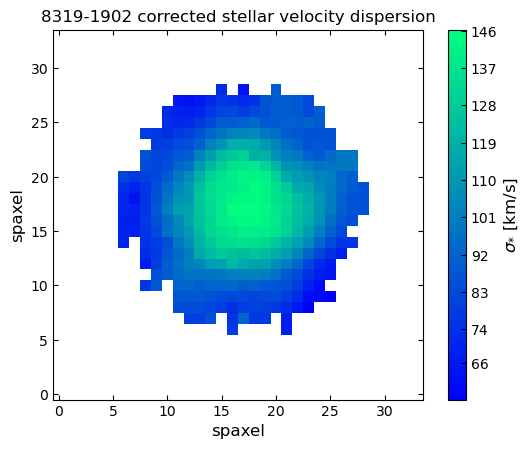

In [64]:
fig, ax = plt.subplots()

cbar_ticks = np.linspace(ma.min(mstar_sigma_corr), ma.max(mstar_sigma_corr), 11, dtype='int')
ax.set_title(gal_ID + ' stellar velocity dispersion', fontsize=12)

vel_im = ax.imshow( mstar_sigma_corr, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=ma.min(mstar_sigma_corr), 
                    vmax=ma.max(mstar_sigma_corr))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=10)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=12) 

ax.tick_params( axis='both', direction='in', labelsize=10)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=12)
ax.set_ylabel('spaxel', fontsize=12)
ax.set_title('8319-1902 corrected stellar velocity dispersion')


plt.savefig(plot_dir + gal_ID + '_stel_sigma_corr.png', bbox_inches='tight', pad_inches=0)

### stellar mass profile

In [166]:
sMass_density = pipe3d_maps['sMass_density']
msMass_density = ma.array(sMass_density, mask=np.isnan(sMass_density))

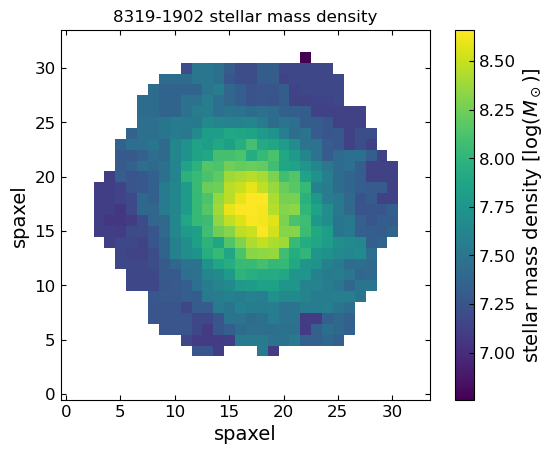

In [167]:
fig, ax = plt.subplots()

vmax = ma.max(msMass_density)
#cbar_ticks = np.linspace( 0, vmax, 11, dtype='int')

ax.set_title(gal_ID + ' stellar mass density', fontsize=12)
############################################################################


############################################################################
# Create plot
#---------------------------------------------------------------------------
vel_im = ax.imshow( msMass_density, 
                    cmap='viridis', 
                    origin='lower', 
                    #vmin=0, 
                    #vmax=vmax
                  )

cbar = plt.colorbar( vel_im, ax=ax)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'stellar mass density $[\log(M_\odot)]$', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)

plt.savefig( plot_dir + gal_ID + '_sMass_density.png', 
             format='png', 
             bbox_inches = 'tight', 
             pad_inches = 0
             )

In [168]:
mass_table = calc_mass_curve(sMass, sMass_err, flux, ba, phi, z)
rs = np.linspace(np.min(mass_table['radius']), np.max(mass_table['radius']), 1000)
sph = exponential_sphere(rs, 10**master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx])
disk = exponential_disk(rs, 10**master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
sphdisk = exponential_sphere_disk(rs, master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx],
                                  master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
mass_table['M_star_err'] = mass_table['M_star_err'] + np.max(mass_table['M_star'])-2.5

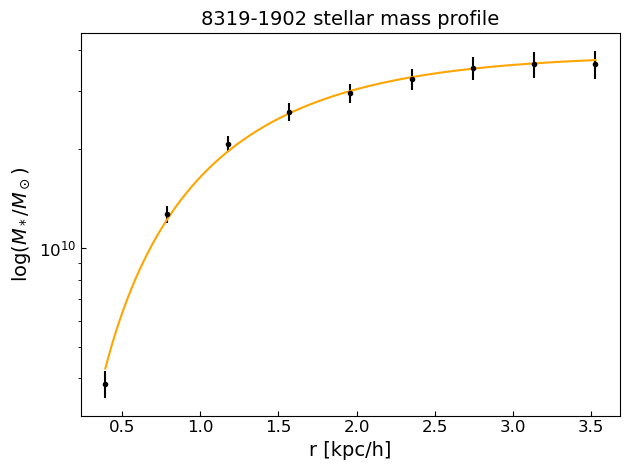

In [169]:
plt.errorbar(mass_table['radius'], 10**mass_table['M_star'], yerr=10**mass_table['M_star_err'], color='k', fmt='.')
# plt.plot(rs, sph, color='dodgerblue', linestyle='--', label='sphere')
# plt.plot(rs, disk, color='crimson', linestyle='--', label='disk')
plt.plot(rs, sphdisk, color='orange')
plt.yscale('log')
plt.xlabel('r [kpc/h]', fontsize=14)
plt.ylabel(r'$\log(M_*/M_\odot)$',fontsize=14)
# ax[1].legend(loc='lower right', )
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.title(gal_ID + ' stellar mass profile', fontsize=14)
plt.tight_layout()
plt.savefig(plot_dir + gal_ID +  '_smass_sphd_fit.png', bbox_inches='tight', pad_inches=0)

### Mstar vs Mr for spirals and ellipticals (within r90) by cmd

In [135]:
blue_spirals = spirals[spirals['CMD_class'] == 1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

In [174]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

e_mstar = []
b_s_mstar = []
g_s_mstar = []
r_s_mstar = []


xp = [-23,-16]
fp = [13, 10.5]
rm_outliers = ellipticals[ellipticals['e_Mstar_R90'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['e_Mstar_R90'][rm_outliers['rabsmag'] <= mag_lim]+np.log10(0.73))
        r_s_mstar.append(red_spirals['M90_disk'][red_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))
        b_s_mstar.append(blue_spirals['M90_disk'][blue_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))
        g_s_mstar.append(green_spirals['M90_disk'][green_spirals['rabsmag'] <= mag_lim]+np.log10(0.73))

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['e_Mstar_R90'][np.logical_and(rm_outliers['rabsmag'] <= mag_lim, 
                                                                         rm_outliers['rabsmag'] > lower_lim)]+np.log10(0.73))
        
        r_s_mstar.append(red_spirals['M90_disk'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))
        b_s_mstar.append(blue_spirals['M90_disk'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))
        g_s_mstar.append(green_spirals['M90_disk'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)]+np.log10(0.73))


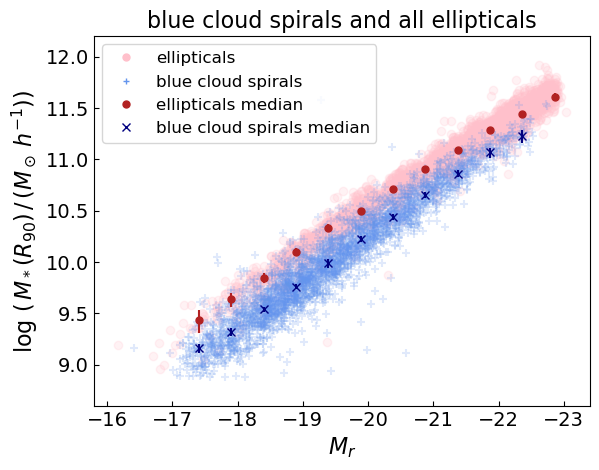

In [137]:
plt.scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), color='pink', marker='o', alpha=0.2, label='ellipticals')
plt.scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
plt.xlim(-15.8, -23.4)
plt.ylim(8.6, 12.2)
plt.title('blue cloud spirals and all ellipticals', fontsize=16)
plt.xlabel(r'$M_r$',fontsize=16)
plt.ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$', fontsize=16)
plt.tick_params( axis='both', direction='in', labelsize=14)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0], 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')




ep_mstar = med_err(b_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='blue cloud spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='blue cloud spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements, fontsize='large')
plt.savefig(plot_dir + 'Mstar_Mr_R90_bcspirals_ellipticals.png', bbox_inches='tight')

In [138]:
def lin_fit(x, a, b):

    return a*x + b

In [1]:
fig, ax = plt.subplots(2,1,sharex=True, height_ratios=(4,1.3), figsize=(6.4,7.2))

ax[0].scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), color='pink', marker='o', alpha=0.2, )
ax[0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2, )
ax[0].set_xlim(-15.8, -23.4)
ax[0].set_ylim(8.6, 12.2)
ax[0].set_title('blue cloud spirals and all ellipticals', fontsize=16)
ax[1].set_xlabel(r'$M_r$',fontsize=16)
ax[0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$', fontsize=16)
ax[1].set_ylabel('linear fit - median')
ax[0].tick_params( axis='both', direction='in', labelsize=14)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0].errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o',linestyle='none', markersize=5, )
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0], 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')

popt1, pcov = curve_fit(lin_fit, pts[:-2], ep_mstar[:-2,0], sigma=ep_mstar[:-2,1])
print(popt)

ax[0].plot(pts, pts*popt1[0] + popt1[1], color='firebrick', label=f'm={popt1[0]:.2}, b={popt1[1]:.2}')

ax[1].plot(pts, pts*popt1[0] + popt1[1] - ep_mstar[:,0], color='firebrick')

popt2, pcov = curve_fit(lin_fit, pts[4:-2], ep_mstar[4:-2,0], sigma=ep_mstar[4:-2,1])
print(popt)
ax[0].plot(pts, pts*popt2[0] + popt2[1], color='firebrick', linestyle='--', label=f'-16>Mr>-21, m={popt2[0]:.2}, b={popt2[1]:.2}')
ax[1].plot(pts, pts*popt2[0] + popt2[1] - ep_mstar[:,0], color='firebrick', linestyle='--')



ep_mstar = med_err(b_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x',linestyle='none', markersize=6,)
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

popt3, pcov = curve_fit(lin_fit, pts[1:-2], ep_mstar[1:-2,0], sigma=ep_mstar[1:-2,1])
print(popt)
ax[0].plot(pts, pts*popt3[0] + popt3[1], color='navy', label=f'm={popt3[0]:.2}, b={popt3[1]:.2}')
ax[1].plot(pts, pts*popt3[0] + popt3[1] - ep_mstar[:,0], color='navy')
popt4, pcov = curve_fit(lin_fit, pts[4:-2], ep_mstar[4:-2,0], sigma=ep_mstar[4:-2,1])
print(popt)
ax[0].plot(pts, pts*popt4[0] + popt4[1], color='navy', linestyle='--', label=f'-16>Mr>-21, m={popt4[0]:.2}, b={popt4[1]:.2}')
ax[1].plot(pts, pts*popt4[0] + popt4[1] - ep_mstar[:,0], color='navy', linestyle='--')


ax[0].legend()
ax[1].axhline(0, color='lightgrey')



# legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
#                           markeredgecolor='pink', markerfacecolor='pink', markersize=5),
#                    Line2D([0], [0], marker='+', color='w', label='blue cloud spirals',
#                           markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
#                   Line2D([0], [0], marker='o', color='w', label='ellipticals median',
#                           markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
#                   Line2D([0], [0], marker='x', color='w', label='blue cloud spirals median',
#                           markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


# plt.legend(handles=legend_elements, fontsize='large')
# plt.savefig(plot_dir + 'Mstar_Mr_R90_bcspirals_ellipticals.png', bbox_inches='tight')

plt.savefig(plot_dir + 'Mstar_Mr_R90_bcspirals_ellipticals_linfit.png', bbox_inches='tight')

NameError: name 'plt' is not defined

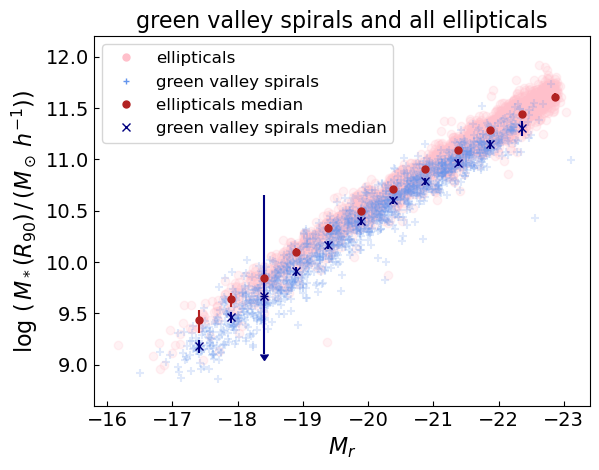

In [140]:
plt.scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), color='pink', marker='o', alpha=0.2, label='ellipticals')
plt.scatter(green_spirals['rabsmag'], green_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2, label='green valley spirals')
plt.xlim(-15.8, -23.4)
plt.ylim(8.6, 12.2)
plt.title('green valley spirals and all ellipticals', fontsize=16)
plt.xlabel(r'$M_r$', fontsize=16)
plt.ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=16)
plt.tick_params( axis='both', direction='in',labelsize=14)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0], 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')




ep_mstar = med_err(g_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0] - 9.1, 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='green valley spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='green valley spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize='large')
plt.savefig(plot_dir + 'Mstar_Mr_R90_gvspirals_ellipticals.png', bbox_inches='tight')

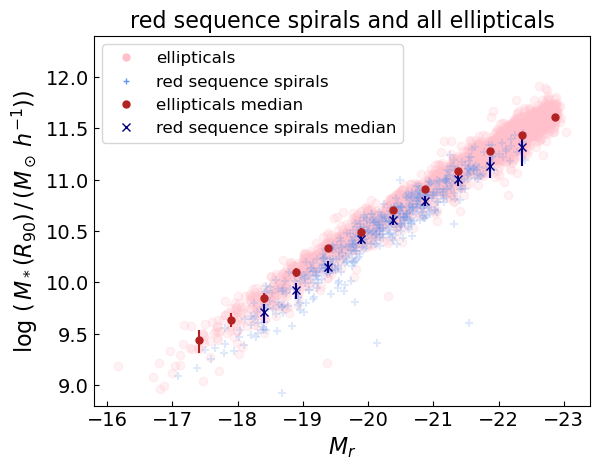

In [141]:
plt.scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), color='pink', marker='o', alpha=0.2, label='ellipticals')
plt.scatter(red_spirals['rabsmag'], red_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
plt.xlim(-15.8, -23.4)
plt.ylim(8.8, 12.4)
plt.title('red sequence spirals and all ellipticals',fontsize=16)
plt.xlabel(r'$M_r$',fontsize=16)
plt.ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=16)
plt.tick_params( axis='both', direction='in',labelsize=14)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0], 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')




ep_mstar = med_err(r_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0] - 9.1, 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='red sequence spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='red sequence spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize='large')
plt.savefig(plot_dir + 'Mstar_Mr_R90_rsspirals_ellipticals.png', bbox_inches='tight')

### Mvir vs Mr ellipticals and spirals by CMD

In [176]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

e_mtot = []
b_s_mtot = []
g_s_mtot = []
r_s_mtot = []


xp = [-23,-16]
fp = [13, 10.5]
# rm_outliers = ellipticals[ellipticals['Mvir'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mtot.append(ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim])
        r_s_mtot.append(red_spirals['M_R90'][red_spirals['rabsmag'] <= mag_lim])
        b_s_mtot.append(blue_spirals['M_R90'][blue_spirals['rabsmag'] <= mag_lim])
        g_s_mtot.append(green_spirals['M_R90'][green_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mtot.append(ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        r_s_mtot.append(red_spirals['M_R90'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)])
        b_s_mtot.append(blue_spirals['M_R90'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)])
        g_s_mtot.append(green_spirals['M_R90'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)])


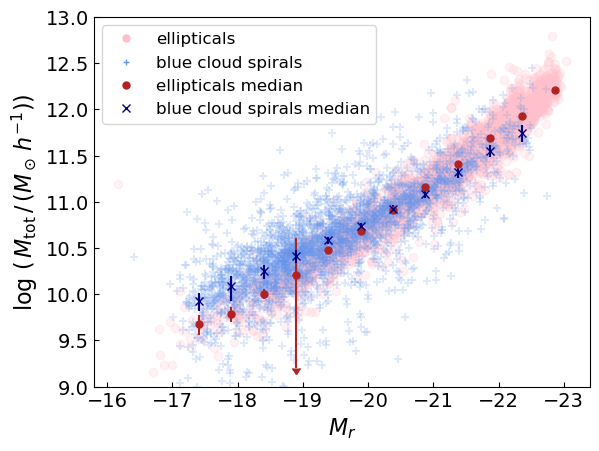

In [144]:
plt.scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='o', alpha=0.2, label='ellipticals')
plt.scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
plt.xlim(-15.8, -23.4)
plt.ylim(9, 13)
# plt.title('blue cloud spirals and all ellipticals')
plt.xlabel(r'$M_r$',fontsize=16)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=16)
plt.tick_params( axis='both', direction='in',labelsize=14)


ep_mstar = med_err(e_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0]-9.2, 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')




ep_mstar = med_err(b_s_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='blue cloud spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='blue cloud spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize='large')
plt.savefig(plot_dir + 'Mtot_Mr_R90_bcspirals_ellipticals.png', bbox_inches='tight')

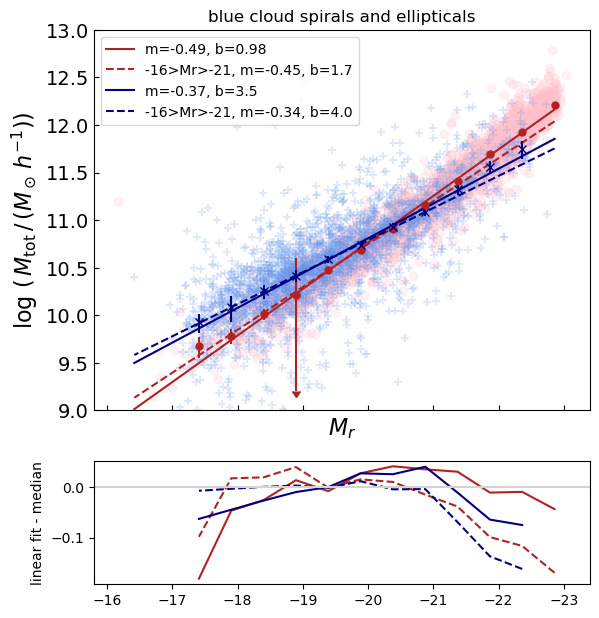

In [177]:
fig, ax = plt.subplots(2,1,sharex=True, height_ratios=(4,1.3), figsize=(6.4,7.2))


ax[0].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='o', alpha=0.2, )
ax[0].scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, )
ax[0].set_xlim(-15.8, -23.4)
ax[0].set_ylim(9, 13)
# plt.title('blue cloud spirals and all ellipticals')
ax[0].set_xlabel(r'$M_r$',fontsize=16)
ax[0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=16)
ax[1].set_ylabel('linear fit - median')
ax[0].tick_params( axis='both', direction='in',labelsize=14)


ep_mstar = med_err(e_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0].errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o',linestyle='none', markersize=5, )
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0]-9.2, 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')




popt5, pcov = curve_fit(lin_fit, pts[:-2], ep_mstar[:-2,0], sigma=ep_mstar[:-2, 2])
ax[0].plot(pts, pts*popt5[0] + popt5[1], color='firebrick', label=f'm={popt5[0]:.{2}}, b={popt5[1]:.{2}}')
ax[1].plot(pts, pts*popt5[0] + popt5[1] - ep_mstar[:,0], color='firebrick')

popt6, pcov = curve_fit(lin_fit, pts[4:-2], ep_mstar[4:-2,0], sigma=ep_mstar[4:-2, 2])
ax[0].plot(pts,pts*popt6[0] + popt6[1], color='firebrick', linestyle='--', label=f'-16>Mr>-21, m={popt6[0]:.{2}}, b={popt6[1]:.{2}}')
ax[1].plot(pts, pts*popt6[0] + popt6[1] - ep_mstar[:,0], color='firebrick', linestyle='--',
           label=f'm={popt6[0]:.{2}}, b={popt6[1]:.{2}}')

ep_mstar = med_err(b_s_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x',linestyle='none', markersize=6,)
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


popt7, pcov = curve_fit(lin_fit, pts[1:-2], ep_mstar[1:-2,0], sigma=ep_mstar[1:-2, 2])
ax[0].plot(pts, pts*popt7[0] + popt7[1], color='navy', label=f'm={popt7[0]:.{2}}, b={popt7[1]:.{2}}')
ax[1].plot(pts, pts*popt7[0] + popt7[1] - ep_mstar[:,0], color='navy',)

popt8, pcov = curve_fit(lin_fit, pts[4:-2], ep_mstar[4:-2,0], sigma=ep_mstar[4:-2, 2])
ax[0].plot(pts,pts*popt8[0] + popt8[1], color='navy', linestyle='--', label=f'-16>Mr>-21, m={popt8[0]:.{2}}, b={popt8[1]:.{2}}')
ax[1].plot(pts, pts*popt8[0] + popt8[1] - ep_mstar[:,0], color='navy',linestyle='--')

ax[0].set_title('blue cloud spirals and ellipticals')
ax[0].legend()

# legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
#                           markeredgecolor='pink', markerfacecolor='pink', markersize=5),
#                    Line2D([0], [0], marker='+', color='w', label='blue cloud spirals',
#                           markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
#                   Line2D([0], [0], marker='o', color='w', label='ellipticals median',
#                           markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
#                   Line2D([0], [0], marker='x', color='w', label='blue cloud spirals median',
#                           markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


# plt.legend(handles=legend_elements,fontsize='large')

ax[1].axhline(0, color='lightgrey')
plt.savefig(plot_dir + 'Mtot_Mr_R90_bcspirals_ellipticals_linfit.png', bbox_inches='tight')

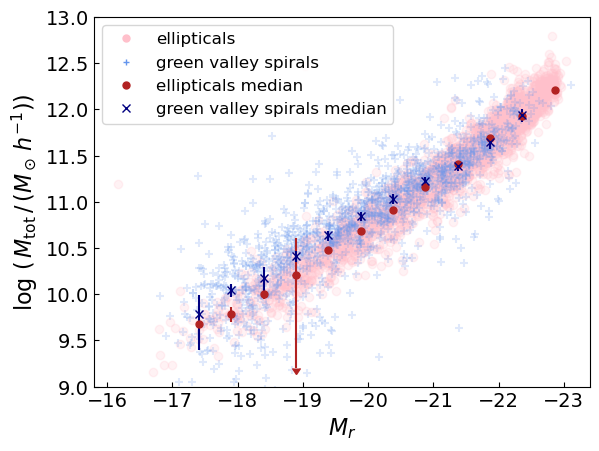

In [30]:
plt.scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='o', alpha=0.2, label='ellipticals')
plt.scatter(green_spirals['rabsmag'], green_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
plt.xlim(-15.8, -23.4)
plt.ylim(9, 13)
# plt.title('green valley spirals and all ellipticals')
plt.xlabel(r'$M_r$',fontsize=16)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=16)
plt.tick_params( axis='both', direction='in', labelsize=14)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0]-9.2, 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')




ep_mstar = med_err(g_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='green valley spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='green valley spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize='large')
plt.savefig(plot_dir + 'Mtot_Mr_R90_gvspirals_ellipticals.png', bbox_inches='tight')

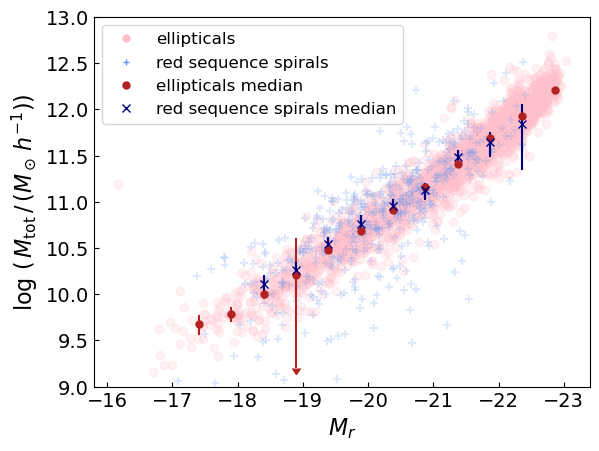

In [32]:
plt.scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='o', alpha=0.2, label='ellipticals')
plt.scatter(red_spirals['rabsmag'], red_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
plt.xlim(-15.8, -23.4)
plt.ylim(9, 13)
# plt.title('red sequence spirals and all ellipticals',fontsize=16)
plt.xlabel(r'$M_r$',fontsize=16)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=16)
plt.tick_params( axis='both', direction='in',labelsize=14)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0]-9.2, 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')




ep_mstar = med_err(r_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='red sequence spiral median',linestyle='none', markersize=6,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='red sequence spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='red sequence spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize='large')
plt.savefig(plot_dir + 'Mtot_Mr_R90_rsspirals_ellipticals.png', bbox_inches='tight')

### combining all mvir, mstar vs mr plots

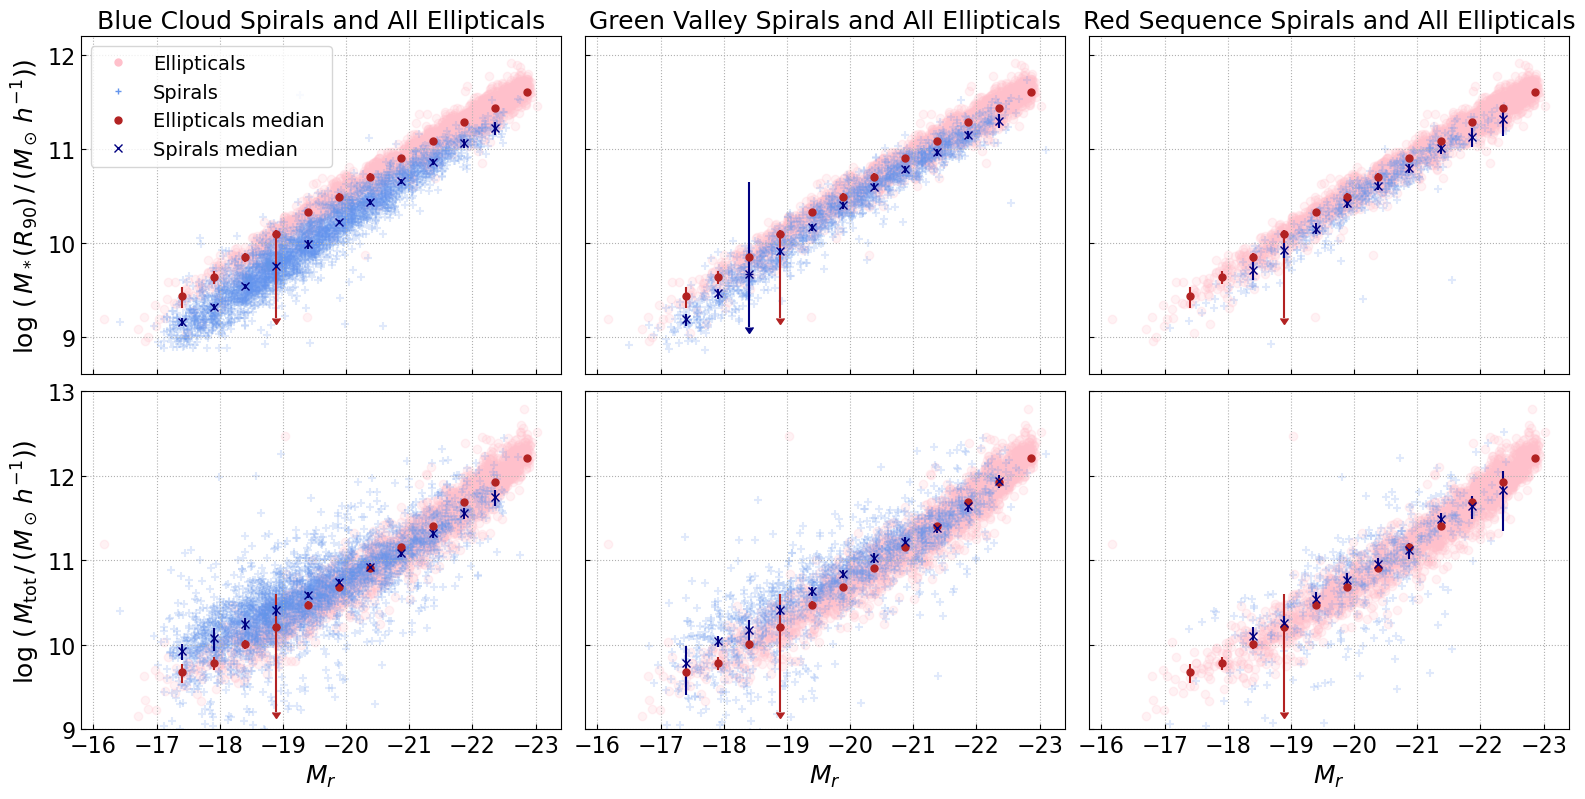

In [52]:
fig, ax = plt.subplots(2,3,sharex=True, sharey='row', figsize=(19.2,9))

# label plots
ax[0,0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[0,1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[0,2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)
ax[0,0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[1,0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=18)

ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]


ep_mtot = med_err(e_mtot)
inf_bars = np.where(ep_mtot == np.inf)[0]
ep_mtot[inf_bars][:,0]

ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
ax[1,0].set_ylim(9,13)
ax[0,0].set_ylim(8.6, 12.2)
ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))


for i in range(0,2):
    for j in range(0,3):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)
        ax[i,j].grid( linestyle=':')


for i in range(0,3):

    ax[1,i].set_xlabel(r'$M_r$', fontsize=18)
    
    ax[1,i].set_xticks(np.arange(-23,-15,1))
    ax[1,i].set_xlim(-15.8, -23.4)
    
    ax[0,i].scatter(ellipticals['rabsmag'], ellipticals['e_Mstar_R90']+np.log10(0.73), color='pink', marker='o', alpha=0.2, label='ellipticals')
    ax[0,i].errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
    ax[0,i].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
                 yerr=ep_mstar[inf_bars][:,0]-9.2, 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
    ax[0,i].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                    linestyle='none', color='firebrick', mfc='none', mec='none')


    
    ax[1,i].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='o', alpha=0.2, label='ellipticals')
    ax[1,i].errorbar(pts, ep_mtot[:,0], color='firebrick', yerr=[ep_mtot[:,1] ,ep_mtot[:,2]], 
                 marker='o', label='elliptical median',linestyle='none', markersize=5, )
    ax[1,i].errorbar(pts[inf_bars], ep_mtot[inf_bars][:,0], 
                 yerr=ep_mtot[inf_bars][:,0]-9.2, 
                 uplims=True,
                 color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
    ax[1,i].errorbar(pts[inf_bars], ep_mtot[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mtot[inf_bars][:,2]],
                    linestyle='none', color='firebrick', mfc='none', mec='none')




legend_elements = [Line2D([0], [0], marker='o', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='Spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


ax[0,0].legend(handles=legend_elements,fontsize=14)



ax[0,0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ep_mstar = med_err(b_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0,0].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[0,0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0,0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ax[0,1].scatter(green_spirals['rabsmag'], green_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2, label='green valley spirals')
ep_mstar = med_err(g_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0,1].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[0,1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0] - 9.1, 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0,1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


ax[0,2].scatter(red_spirals['rabsmag'], red_spirals['M90_disk']+np.log10(0.73), color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
ep_mstar = med_err(r_s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0,2].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[0,2].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0] - 9.1, 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0,2].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')



ax[1,0].scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ep_mstar = med_err(b_s_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[1,0].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[1,0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


ax[1,1].scatter(green_spirals['rabsmag'], green_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ep_mstar = med_err(g_s_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[1,1].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[1,1].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')



ax[1,2].scatter(red_spirals['rabsmag'], red_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
ep_mstar = med_err(r_s_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[1,2].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
                 marker='x', label='red sequence spiral median',linestyle='none', markersize=6,)
ax[1,2].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[1,2].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.savefig(plot_dir + 'Mtot_Mstar_Mr_CMDspiral_ellipticals.png', bbox_inches='tight')

### mvir vs mstar ellipticals

(array([5.900e+01, 4.430e+02, 1.264e+03, 6.820e+02, 4.000e+00, 3.000e+00,
        1.000e+00, 2.000e+00, 1.000e+00, 1.000e+00]),
 array([ 8.97711981,  9.78207719, 10.58703457, 11.39199194, 12.19694932,
        13.0019067 , 13.80686408, 14.61182146, 15.41677884, 16.22173622,
        17.0266936 ]),
 <BarContainer object of 10 artists>)

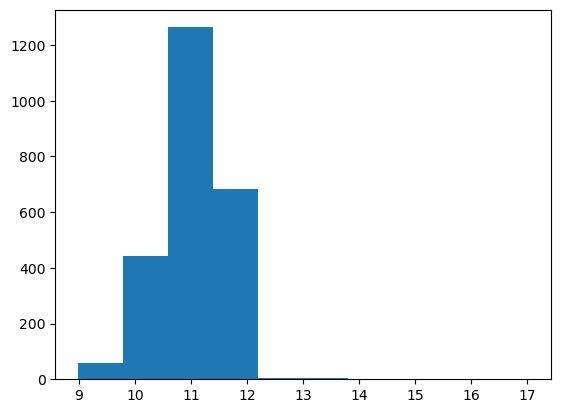

In [63]:
plt.hist(ellipticals['sphd_M_star']+np.log10(0.73))

In [65]:
np.max(ellipticals['sphd_M_star']+np.log10(0.73))

17.026693599694266

In [15]:
bins = np.linspace(8.8,
                  11.8, 15)
pts = (bins[:-1] + bins [1:]) / 2

e_mstar = []


# xp = [-23,-16]
# fp = [13, 10.5]
# rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        
    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])


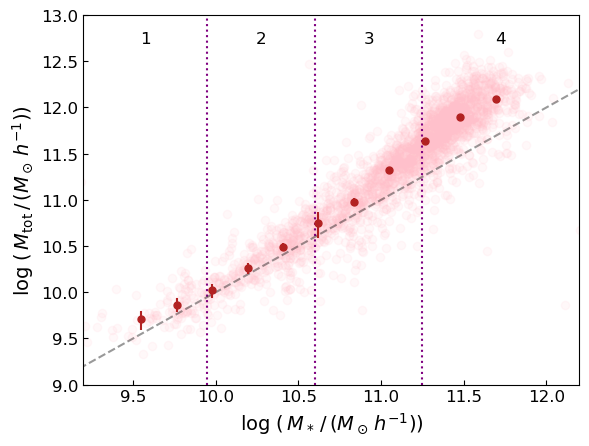

In [16]:
plt.axvline(9.95, color='purple', alpha=1, linestyle=':')
plt.axvline(10.6, color='purple', alpha=1,linestyle=':')
plt.axvline(11.25, color='purple', alpha=1,linestyle=':')

plt.scatter(ellipticals['sphd_M_star']+np.log10(0.73), ellipticals['Mvir'], color='pink', alpha=0.1, label='ellipticals')


plt.xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlim(9.2,12.2)
plt.ylim(9,13)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
plt.tick_params( axis='both', direction='in',labelsize=12)
plt.plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')

plt.text((9.2+9.95)/2,12.7,'1', fontsize=12, ha='center')
plt.text((9.95+10.6)/2,12.7,'2', fontsize=12,ha='center')
plt.text((10.6 + 11.25)/2,12.7,'3', fontsize=12,ha='center')
plt.text((11.25+12.2)/2,12.7,'4', fontsize=12,ha='center')


plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_median.png')

<ErrorbarContainer object of 3 artists>

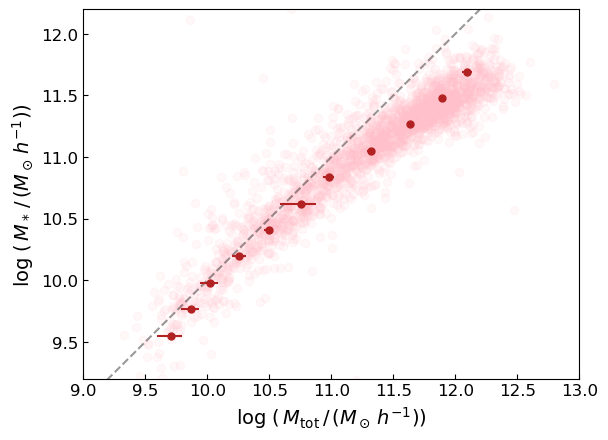

In [15]:
# plt.axvline(9.95, color='purple', alpha=1, linestyle=':')
# plt.axvline(10.6, color='purple', alpha=1,linestyle=':')
# plt.axvline(11.25, color='purple', alpha=1,linestyle=':')

plt.scatter(ellipticals['Mvir'], ellipticals['sphd_M_star']+np.log10(0.73), color='pink', alpha=0.1, label='ellipticals')


plt.ylabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.ylim(9.2,12.2)
plt.xlim(9,13)
plt.xlabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
plt.tick_params( axis='both', direction='in',labelsize=12)
plt.plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar( ep_mstar[:,0],pts, color='firebrick', xerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar( ep_mstar[inf_bars][:,0], pts[inf_bars],
             xerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(ep_mstar[inf_bars][:,0], pts[inf_bars], xerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')

# plt.text((9.2+9.95)/2,12.7,'1', fontsize=12, ha='center')
# plt.text((9.95+10.6)/2,12.7,'2', fontsize=12,ha='center')
# plt.text((10.6 + 11.25)/2,12.7,'3', fontsize=12,ha='center')
# plt.text((11.25+12.2)/2,12.7,'4', fontsize=12,ha='center')


# plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_median.png')

(array([1.356e+03, 9.840e+02, 1.020e+02, 1.200e+01, 3.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([0.24338244, 0.31469439, 0.38600634, 0.45731829, 0.52863024,
        0.59994219, 0.67125413, 0.74256608, 0.81387803, 0.88518998,
        0.95650193]),
 <BarContainer object of 10 artists>)

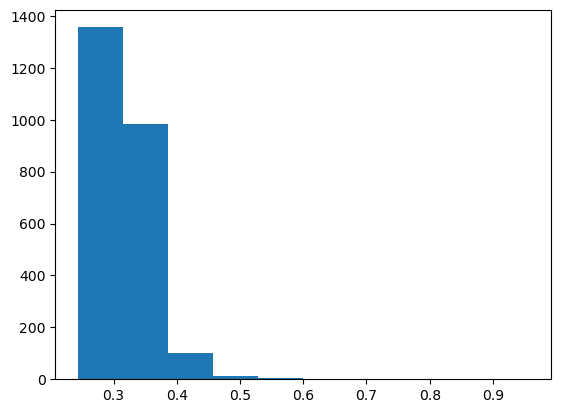

In [37]:
plt.hist(ellipticals['nsa_elpetro_th50_r']/ellipticals['nsa_elpetro_th90'])

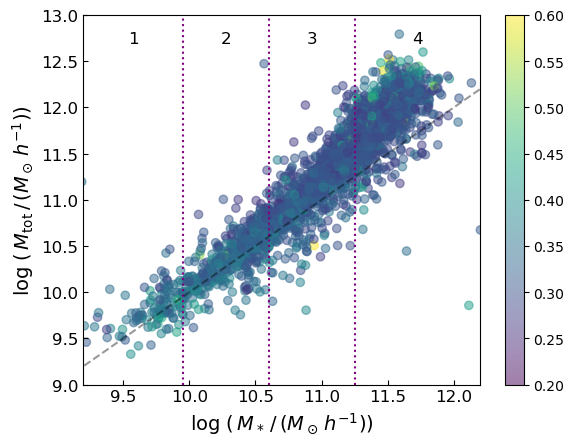

In [46]:
plt.axvline(9.95, color='purple', alpha=1, linestyle=':')
plt.axvline(10.6, color='purple', alpha=1,linestyle=':')
plt.axvline(11.25, color='purple', alpha=1,linestyle=':')

plt.scatter(ellipticals['sphd_M_star']+np.log10(0.73), ellipticals['Mvir'], 
            c=ellipticals['nsa_elpetro_th50_r']/ellipticals['nsa_elpetro_th90'], alpha=0.5, label='ellipticals',
           vmin=0.2, vmax=0.6)


plt.xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlim(9.2,12.2)
plt.ylim(9,13)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
plt.tick_params( axis='both', direction='in',labelsize=12)
plt.plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)


# ep_mstar = med_err(e_mstar)
# inf_bars = np.where(ep_mstar == np.inf)[0]
# ep_mstar[inf_bars][:,0]

# plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
#              marker='o', label='elliptical median',linestyle='none', markersize=5, )
# plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
#              yerr=ep_mstar[inf_bars][:,0]-9, 
#              uplims=True,
#              color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
# plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
#                 linestyle='none', color='firebrick', mfc='none', mec='none')

plt.text((9.2+9.95)/2,12.7,'1', fontsize=12, ha='center')
plt.text((9.95+10.6)/2,12.7,'2', fontsize=12,ha='center')
plt.text((10.6 + 11.25)/2,12.7,'3', fontsize=12,ha='center')
plt.text((11.25+12.2)/2,12.7,'4', fontsize=12,ha='center')
plt.colorbar()


# plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_median.png')

### mvis vs mtot for spirals and ellipticals

In [18]:
HI_spirals = spirals[spirals['logHI_R90']>0]
# find total HI and total stellar mass for the spirals

HI_spirals['Mstar_tot'] = np.log10(8 * np.pi * HI_spirals['R_bulge']**3 * HI_spirals['rho_bulge'] + 2 * np.pi * HI_spirals['Sigma_disk'] * HI_spirals['R_disk']**2)

In [19]:
bins = np.linspace(8.8,
                  11.8, 15)
pts = (bins[:-1] + bins [1:]) / 2

s_mvis = np.log10(10**(HI_spirals['Mstar_tot']+np.log10(0.73)) + 10**(HI_spirals['logHI'] + np.log10(0.7)))

e_mstar = []
s_mstar = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        s_mstar.append(HI_spirals['M_R90'][s_mvis <= mag_lim])
        
    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        
        s_mstar.append(HI_spirals['M_R90'][np.logical_and(s_mvis<= mag_lim, s_mvis > lower_lim)])


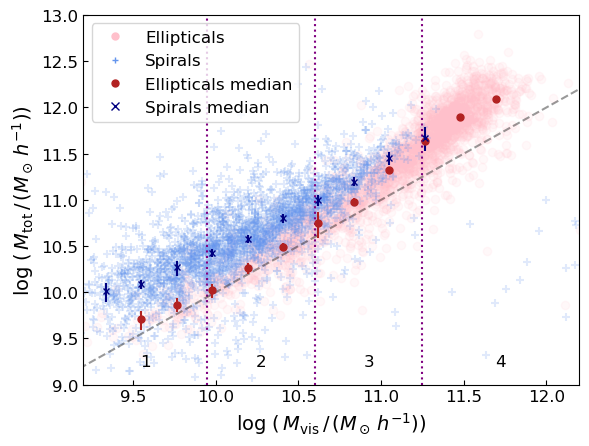

In [22]:
plt.axvline(9.95, color='purple', alpha=1, linestyle=':')
plt.axvline(10.6, color='purple', alpha=1,linestyle=':')
plt.axvline(11.25, color='purple', alpha=1,linestyle=':')

plt.scatter(ellipticals['sphd_M_star']+np.log10(0.73), ellipticals['Mvir'], color='pink', alpha=0.1, label='Ellipticals')
plt.scatter(np.log10(10**(HI_spirals['Mstar_tot']+np.log10(0.73)) + 10**(HI_spirals['logHI']+np.log10(0.7))), HI_spirals['M_R90'], 
            color='cornflowerblue', alpha=0.2, marker='+', label='Spirals')


plt.xlabel(r'$\log\,(\,M_{\rm vis}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlim(9.2,12.2)
plt.ylim(9,13)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
plt.tick_params( axis='both', direction='in',labelsize=12)
plt.plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='Ellipticals median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')

ep_mstar = med_err(s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='x', label='Spirals median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='navy', mfc='none', mec='none')

# plt.text((9.2+9.95)/2,12.7,'1', fontsize=12, ha='center')
# plt.text((9.95+10.6)/2,12.7,'2', fontsize=12,ha='center')
# plt.text((10.6 + 11.25)/2,12.7,'3', fontsize=12,ha='center')
# plt.text((11.25+12.2)/2,12.7,'4', fontsize=12,ha='center')
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals median',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='x', color='w', label='Spirals median',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize=12)


plt.text((9.2+9.95)/2,9.2,'1', fontsize=12, ha='center')
plt.text((9.95+10.6)/2,9.2,'2', fontsize=12,ha='center')
plt.text((10.6 + 11.25)/2,9.2,'3', fontsize=12,ha='center')
plt.text((11.25+12.2)/2,9.2,'4', fontsize=12,ha='center')

plt.savefig(plot_dir + 'Mvis_Mtot_ellipticals_median.png')

In [30]:
bins = np.linspace(8.8,
                  11.8, 15)
pts = (bins[:-1] + bins [1:]) / 2

s_mvis = (HI_spirals['Mstar_tot']+np.log10(0.73))

e_mstar = []
s_mstar = []


for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        s_mstar.append(HI_spirals['M_R90'][s_mvis <= mag_lim])
        
    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        
        s_mstar.append(HI_spirals['M_R90'][np.logical_and(s_mvis<= mag_lim, s_mvis > lower_lim)])


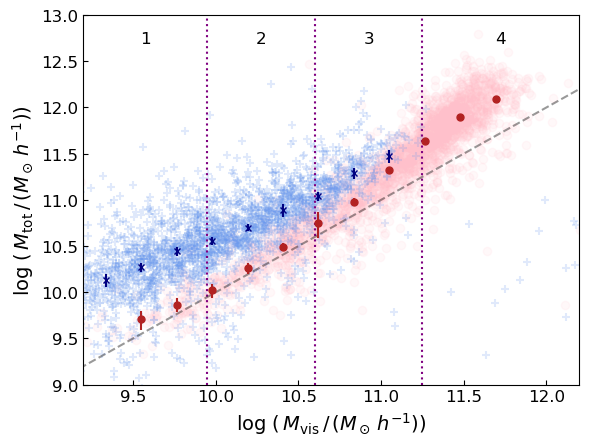

In [31]:
plt.axvline(9.95, color='purple', alpha=1, linestyle=':')
plt.axvline(10.6, color='purple', alpha=1,linestyle=':')
plt.axvline(11.25, color='purple', alpha=1,linestyle=':')

plt.scatter(ellipticals['sphd_M_star']+np.log10(0.73), ellipticals['Mvir'], color='pink', alpha=0.1, label='ellipticals')
plt.scatter(HI_spirals['Mstar_tot']+np.log10(0.73), HI_spirals['M_R90'], 
            color='cornflowerblue', alpha=0.2, marker='+', label='spirals')


plt.xlabel(r'$\log\,(\,M_{\rm vis}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlim(9.2,12.2)
plt.ylim(9,13)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
plt.tick_params( axis='both', direction='in',labelsize=12)
plt.plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)


ep_mstar = med_err(e_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')

ep_mstar = med_err(s_mstar)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

plt.errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='x', label='spiral median',linestyle='none', markersize=5, )
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='navy', mfc='none', mec='none')

plt.text((9.2+9.95)/2,12.7,'1', fontsize=12, ha='center')
plt.text((9.95+10.6)/2,12.7,'2', fontsize=12,ha='center')
plt.text((10.6 + 11.25)/2,12.7,'3', fontsize=12,ha='center')
plt.text((11.25+12.2)/2,12.7,'4', fontsize=12,ha='center')


plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_spirals_median.png')

### nsa vs pipe3d comparison

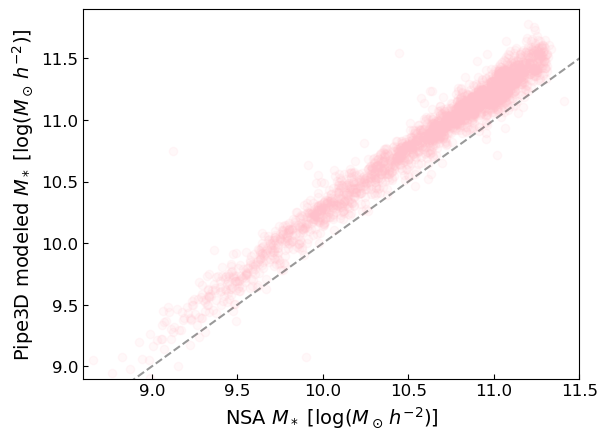

In [111]:
plt.scatter(ellipticals['nsa_elpetro_log_mass'], ellipticals['e_Mstar_R90'] + np.log10(0.73**2), color='pink', alpha=0.1)
plt.plot([8,12.5],[8,12.5], color='k', alpha=0.4, linestyle='--')
plt.xlim(8.6,11.5)
plt.ylim(8.9,11.9)
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.xlabel(r'NSA $M_*$ $[\log(M_\odot\,h^{-2})]$', fontsize=14)
plt.ylabel(r'Pipe3D modeled $M_*$ $[\log(M_\odot\,h^{-2})]$', fontsize=14)
plt.savefig(plot_dir + 'nsa_pipe3d_model_mstar_compare.png')

In [14]:
print(ma.mean(ellipticals['e_Mstar_R90']+ np.log10(0.73**2) - ellipticals['nsa_elpetro_log_mass']))
print(ma.median(ellipticals['e_Mstar_R90']+ np.log10(0.73**2) - ellipticals['nsa_elpetro_log_mass']))

0.24552363692992502
0.24911255337619131


### agn bpt 

In [13]:
BPT_dict = {1.0: 'slateblue',
            2.0: 'limegreen',
            3.0:'lightcoral',
            0: 'k',}

BPT_m_dict = {1.0: 's',
              2.0: '^',
              3.0: 'o',
             0: '.'}
BPT_s_dict = {1.0: 5,
              2.0: 10,
              3.0: 10,
             0: 1}

def dust_corr(Ha, Hb, N2, O3, corr_law='CCM89'):
    
    rc= pn.RedCorr(law=corr_law)

    H_ratio = Ha/Hb

    rc.setCorr(H_ratio / 2.86, 6562, 4861)

    # in order Ha, Hb, NII, OIII
    wavelengths = np.array([6562, 4861, 6583, 5006])
    corr = rc.getCorrHb(wavelengths)

    Ha_corr = Ha * corr[0]
    Hb_corr = Hb * corr[1]
    N2_corr = N2 * corr[2]
    O3_corr = O3 * corr[3]

    return Ha_corr, Hb_corr, N2_corr, O3_corr

[WARNING]: /var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_36760/4163645990.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  H_ratio = Ha/Hb

[WARNING]: /Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:252: RuntimeWarning: invalid value encountered in divide
  return np.squeeze(10. ** (0.4 * np.outer(X, self.E_BV).reshape(X.shape + self.E_BV.shape))) / rel_corr

[WARNING]: /Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:316: RuntimeWarning: divide by zero encountered in log10
  self.E_BV = 2.5 * np.log10(obs_over_theo) / (f1 - f2)

[WARNING]: /var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_36760/1685713179.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(N2/Ha),

[WARNING]: /var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_36760/4163645990.py:19: RuntimeWarning: invalid value encountered in

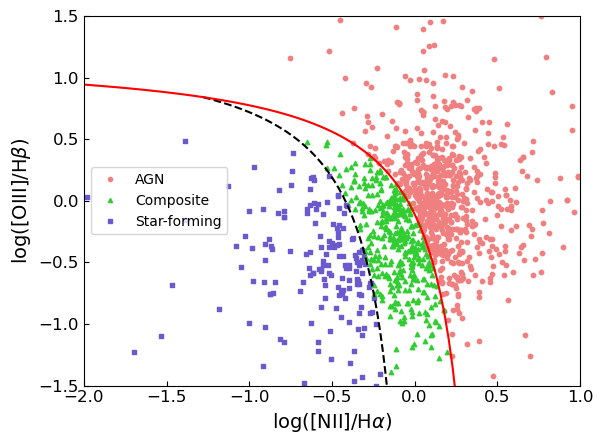

In [14]:
for i in range(len(ellipticals)):
    
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]


    Ha, Hb, N2, O3 = dust_corr(nsa_portsmouth['Flux_Ha_6562'][nsa_idx], nsa_portsmouth['Flux_Hb_4861'][nsa_idx],
                               nsa_portsmouth['Flux_NII_6583'][nsa_idx], nsa_portsmouth['Flux_OIII_5006'][nsa_idx])

    plt.scatter(np.log10(N2/Ha),
                    np.log10(O3/Hb),
                    marker=BPT_m_dict[ellipticals[i]['BPT_class']], color=BPT_dict[ellipticals[i]['BPT_class']],
                    alpha=1, s=BPT_s_dict[ellipticals[i]['BPT_class']]
               )

plt.xlim(-2,1)
plt.ylim(-1.5,1.5)

x = np.linspace(-1.28,0,100)
plt.plot(x,0.61/(x-0.05) + 1.3, color='k', linestyle='--')
x1 = np.linspace(-2,0.4,100)
plt.plot(x1,0.61/(x1 - 0.47) + 1.19, color='r')

plt.xlabel(r'log([NII]/H$\alpha$)', fontsize=14)
plt.ylabel(r'log([OIII]/H$\beta$)', fontsize=14)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue',markersize=3)]
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.legend(handles=legend_elements)
plt.savefig(plot_dir + 'ellipticals_BPT.png', bbox_inches='tight')

In [23]:
u_ellipticals = ellipticals[ellipticals['BPT_class']==0]
sf_ellipticals = ellipticals[ellipticals['BPT_class']==1]
c_ellipticals = ellipticals[ellipticals['BPT_class']==2]
agn_ellipticals = ellipticals[ellipticals['BPT_class']==3]

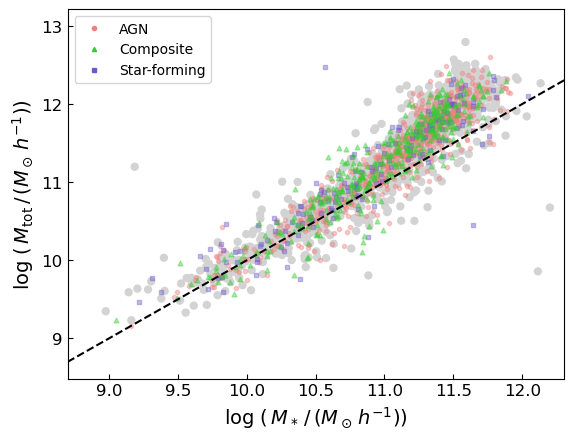

In [24]:
plt.scatter(u_ellipticals['sphd_M_star']+np.log10(0.73), u_ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
plt.scatter(agn_ellipticals['sphd_M_star']+np.log10(0.73), agn_ellipticals['Mvir'], color='lightcoral', marker='.', alpha=0.4)
plt.scatter(sf_ellipticals['sphd_M_star']+np.log10(0.73), sf_ellipticals['Mvir'], color='slateblue', marker='s', alpha=0.4, s=8)
plt.scatter(c_ellipticals['sphd_M_star']+np.log10(0.73), c_ellipticals['Mvir'], color='limegreen', marker='^', alpha=0.4, s=12)
plt.xlim(8.7,12.3)
plt.xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue', markersize=3)]
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.plot([8.7,13],[8.7,13], color='k', linestyle='--')


plt.legend(handles=legend_elements)
plt.savefig(plot_dir + 'Mtot_Mstar_BPT.png', bbox_inches='tight')

In [30]:
bins = np.linspace(9.3,11.9,5)
bin1 = ellipticals[ellipticals['sphd_M_star']+np.log10(0.73) < bins[1]]
bin2 = ellipticals[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) > bins[1], ellipticals['sphd_M_star']+np.log10(0.73) < bins[2])]
bin3 = ellipticals[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) > bins[2], ellipticals['sphd_M_star']+np.log10(0.73) < bins[3])]
bin4 = ellipticals[ellipticals['sphd_M_star']+np.log10(0.73) > bins[3]]

In [31]:
bins

array([ 9.3 ,  9.95, 10.6 , 11.25, 11.9 ])

In [64]:
all_mtot = []
agn_mtot = []
sf_mtot = []
c_mtot = []

ellipticals_mtot_mstar = ellipticals['Mvir'] - (ellipticals['sphd_M_star']+np.log10(0.73))
agn_ellipticals_mtot_mstar = agn_ellipticals['Mvir'] - (agn_ellipticals['sphd_M_star']+np.log10(0.73))

c_ellipticals_mtot_mstar = c_ellipticals['Mvir'] - (c_ellipticals['sphd_M_star']+np.log10(0.73))
sf_ellipticals_mtot_mstar = sf_ellipticals['Mvir'] - (sf_ellipticals['sphd_M_star']+np.log10(0.73))



for i in range(4):
    mag_lim = bins[i+1]
    if i == 0:
        all_mtot.append(ellipticals_mtot_mstar[ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim] )
        agn_mtot.append(agn_ellipticals_mtot_mstar[agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        sf_mtot.append(sf_ellipticals_mtot_mstar[sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])
        c_mtot.append(c_ellipticals_mtot_mstar[c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim])

    elif i == 3:
        mag_lim = bins[i]
        all_mtot.append(ellipticals_mtot_mstar[ellipticals['sphd_M_star']+np.log10(0.73) > mag_lim])
        agn_mtot.append(agn_ellipticals_mtot_mstar[agn_ellipticals['sphd_M_star']+np.log10(0.73) > mag_lim])
        sf_mtot.append(sf_ellipticals_mtot_mstar[sf_ellipticals['sphd_M_star']+np.log10(0.73) > mag_lim])
        c_mtot.append(c_ellipticals_mtot_mstar[c_ellipticals['sphd_M_star']+np.log10(0.73) > mag_lim])
        
    else:
        lower_lim = bins[i]
        all_mtot.append(ellipticals_mtot_mstar[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        agn_mtot.append(agn_ellipticals_mtot_mstar[np.logical_and(agn_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         agn_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        sf_mtot.append(sf_ellipticals_mtot_mstar[np.logical_and(sf_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         sf_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])
        c_mtot.append(c_ellipticals_mtot_mstar[np.logical_and(c_ellipticals['sphd_M_star']+np.log10(0.73) <= mag_lim, 
                                                                         c_ellipticals['sphd_M_star']+np.log10(0.73) > lower_lim)])


array([[0.09305808, 0.54592623, 0.23439213],
       [0.07554967, 0.08654028, 0.07212793],
       [0.22657124, 0.0206387 , 0.01970224],
       [0.40603373, 0.01692893, 0.01629372]])

In [68]:
med_err?

Signature: med_err(vals, logscale=True, return_logscale=True)
Docstring:
Takes a a list of values in bins, calculates the log median and uncertainty (RMS/sqrt(N)) and returns log median and log err bars

vals : array
    2D array of dimension (N,M) corresponding to N bins in histogram
File:      ~/Documents/Github/RotationCurves/ellipticals/elliptical_plottingFunctions.py
Type:      function

Text(0, 0.5, '$M_{\\rm tot}\\, /\\, M_*$')

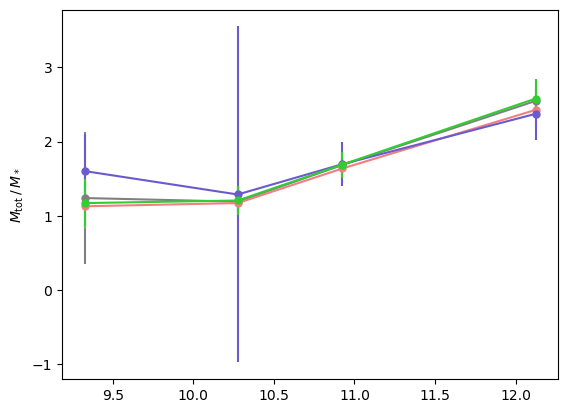

In [93]:
bin_edges = np.array([8.7,9.95,10.6,11.25,13])
bin_ctrs = (bin_edges[:4] + bin_edges[1:])/2



ep_mstar = med_err(all_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(bin_ctrs, ep_mstar[:,0], color='grey', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', markersize=5, )
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='grey', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='grey', mfc='none', mec='none')

ep_mstar = med_err(agn_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(bin_ctrs, ep_mstar[:,0], color='lightcoral', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', markersize=5, )
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='lightcoral', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='lightcoral', mfc='none', mec='none')

ep_mstar = med_err(sf_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(bin_ctrs, ep_mstar[:,0], color='slateblue', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', markersize=5, )
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]+1, 
             uplims=True,
             color='slateblue', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='slateblue', mfc='none', mec='none')

ep_mstar = med_err(c_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(bin_ctrs, ep_mstar[:,0], color='limegreen', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', markersize=5, )
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='limegreen', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='limegreen', mfc='none', mec='none')

# plt.ylim(0.7,2.8)
plt.ylabel(r'$M_{\rm tot}\, /\, M_*$')

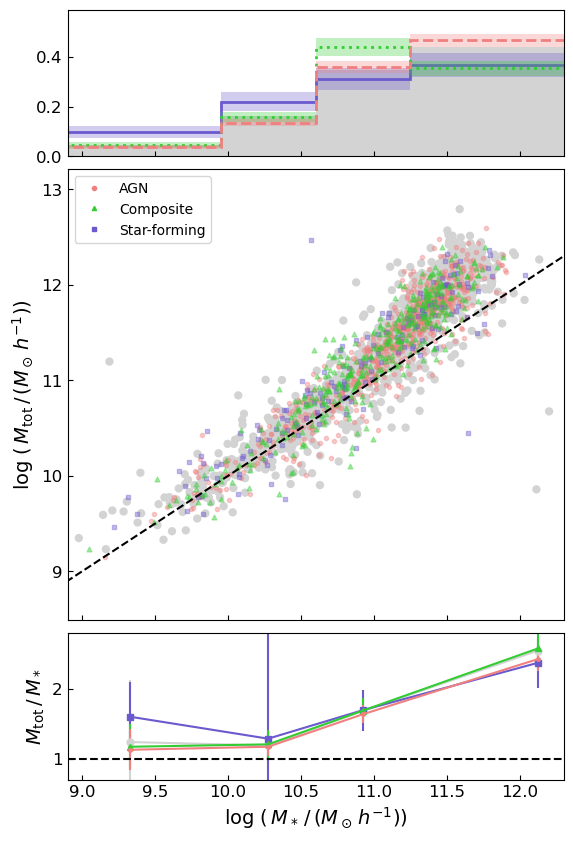

In [92]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(bin1)/len(ellipticals),len(bin2)/len(ellipticals),
              len(bin3)/len(ellipticals), len(bin4)/len(ellipticals)], [8.7,9.95,10.6,11.25,13], 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')





             
ax[0].stairs([len(bin1[bin1['BPT_class']==1])/len(sf_ellipticals),len(bin2[bin2['BPT_class']==1])/len(sf_ellipticals),
              len(bin3[bin3['BPT_class']==1])/len(sf_ellipticals), len(bin4[bin4['BPT_class']==1])/len(sf_ellipticals)], [8.7,9.95,10.6,11.25,13],
             color='slateblue', alpha=1, label=r'sf', lw=2)

ax[0].stairs([(len(bin1[bin1['BPT_class']==1])+np.sqrt(len(bin1[bin1['BPT_class']==1])))/len(sf_ellipticals),
              (len(bin2[bin2['BPT_class']==1])+np.sqrt(len(bin2[bin2['BPT_class']==1])))/len(sf_ellipticals),
              (len(bin3[bin3['BPT_class']==1])+np.sqrt(len(bin3[bin3['BPT_class']==1])))/len(sf_ellipticals),
               (len(bin4[bin4['BPT_class']==1])+np.sqrt(len(bin4[bin4['BPT_class']==1])))/len(sf_ellipticals)], 
                [8.7,9.95,10.6,11.25,13],
                baseline=[(len(bin1[bin1['BPT_class']==1])-np.sqrt(len(bin1[bin1['BPT_class']==1])))/len(sf_ellipticals),
              (len(bin2[bin2['BPT_class']==1])-np.sqrt(len(bin2[bin2['BPT_class']==1])))/len(sf_ellipticals),
              (len(bin3[bin3['BPT_class']==1])-np.sqrt(len(bin3[bin3['BPT_class']==1])))/len(sf_ellipticals),
               (len(bin4[bin4['BPT_class']==1])-np.sqrt(len(bin4[bin4['BPT_class']==1])))/len(sf_ellipticals)],
             color='slateblue', alpha=0.3, label=r'sf', lw=2, fill=True)

ax[0].stairs([len(bin1[bin1['BPT_class']==2])/len(c_ellipticals),len(bin2[bin2['BPT_class']==2])/len(c_ellipticals),
              len(bin3[bin3['BPT_class']==2])/len(c_ellipticals), len(bin4[bin4['BPT_class']==2])/len(c_ellipticals)], [8.7,9.95,10.6,11.25,13],
             color='limegreen', alpha=1, label=r'sf', linestyle=':',lw=2)

ax[0].stairs([(len(bin1[bin1['BPT_class']==2])+np.sqrt(len(bin1[bin1['BPT_class']==2])))/len(c_ellipticals),
              (len(bin2[bin2['BPT_class']==2])+np.sqrt(len(bin2[bin2['BPT_class']==2])))/len(c_ellipticals),
              (len(bin3[bin3['BPT_class']==2])+np.sqrt(len(bin3[bin3['BPT_class']==2])))/len(c_ellipticals),
               (len(bin4[bin4['BPT_class']==2])+np.sqrt(len(bin4[bin4['BPT_class']==2])))/len(c_ellipticals)], 
                [8.7,9.95,10.6,11.25,13],
                baseline=[(len(bin1[bin1['BPT_class']==2])-np.sqrt(len(bin1[bin1['BPT_class']==2])))/len(c_ellipticals),
              (len(bin2[bin2['BPT_class']==2])-np.sqrt(len(bin2[bin2['BPT_class']==2])))/len(c_ellipticals),
              (len(bin3[bin3['BPT_class']==2])-np.sqrt(len(bin3[bin3['BPT_class']==2])))/len(c_ellipticals),
               (len(bin4[bin4['BPT_class']==2])-np.sqrt(len(bin4[bin4['BPT_class']==2])))/len(c_ellipticals)],
             color='limegreen', alpha=0.3, label=r'sf', lw=2, fill=True)


ax[0].stairs([len(bin1[bin1['BPT_class']==3])/len(agn_ellipticals),len(bin2[bin2['BPT_class']==3])/len(agn_ellipticals),
              len(bin3[bin3['BPT_class']==3])/len(agn_ellipticals), len(bin4[bin4['BPT_class']==3])/len(agn_ellipticals)], [8.7,9.95,10.6,11.25,13],
             color='lightcoral', alpha=1, label=r'sf', linestyle='--', lw=2)


ax[0].stairs([(len(bin1[bin1['BPT_class']==3])+np.sqrt(len(bin1[bin1['BPT_class']==3])))/len(agn_ellipticals),
              (len(bin2[bin2['BPT_class']==3])+np.sqrt(len(bin2[bin2['BPT_class']==3])))/len(agn_ellipticals),
              (len(bin3[bin3['BPT_class']==3])+np.sqrt(len(bin3[bin3['BPT_class']==3])))/len(agn_ellipticals),
               (len(bin4[bin4['BPT_class']==3])+np.sqrt(len(bin4[bin4['BPT_class']==3])))/len(agn_ellipticals)], 
                [8.7,9.95,10.6,11.25,13],
                baseline=[(len(bin1[bin1['BPT_class']==3])-np.sqrt(len(bin1[bin1['BPT_class']==3])))/len(agn_ellipticals),
              (len(bin2[bin2['BPT_class']==3])-np.sqrt(len(bin2[bin2['BPT_class']==3])))/len(agn_ellipticals),
              (len(bin3[bin3['BPT_class']==3])-np.sqrt(len(bin3[bin3['BPT_class']==3])))/len(agn_ellipticals),
               (len(bin4[bin4['BPT_class']==3])-np.sqrt(len(bin4[bin4['BPT_class']==3])))/len(agn_ellipticals)],
             color='lightcoral', alpha=0.3, label=r'sf', lw=2, fill=True)




ax[1].scatter(u_ellipticals['sphd_M_star']+np.log10(0.73), u_ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
ax[1].scatter(agn_ellipticals['sphd_M_star']+np.log10(0.73), agn_ellipticals['Mvir'], color='lightcoral', marker='.', alpha=0.4)
ax[1].scatter(sf_ellipticals['sphd_M_star']+np.log10(0.73), sf_ellipticals['Mvir'], color='slateblue', marker='s', alpha=0.4, s=8)
ax[1].scatter(c_ellipticals['sphd_M_star']+np.log10(0.73), c_ellipticals['Mvir'], color='limegreen', marker='^', alpha=0.4, s=12)
ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)


bin_edges = np.array([8.7,9.95,10.6,11.25,13])
bin_ctrs = (bin_edges[:4] + bin_edges[1:])/2



ep_mstar = med_err(all_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
ax[2].errorbar(bin_ctrs, ep_mstar[:,0], color='lightgrey', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', markersize=5, )
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='lightgrey', linestyle='none', capsize=3, mfc='none', mec='none')
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='lightgrey', mfc='none', mec='none')


ep_mstar = med_err(sf_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
ax[2].errorbar(bin_ctrs, ep_mstar[:,0], color='slateblue', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='s', markersize=5, )
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]+1, 
             uplims=True,
             color='slateblue', linestyle='none', capsize=3, mfc='none', mec='none')
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='slateblue', mfc='none', mec='none')

ep_mstar = med_err(c_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
ax[2].errorbar(bin_ctrs, ep_mstar[:,0], color='limegreen', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='^', markersize=5, )
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='limegreen', linestyle='none', capsize=3, mfc='none', mec='none')
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='limegreen', mfc='none', mec='none')

ep_mstar = med_err(agn_mtot, True, False)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
ax[2].errorbar(bin_ctrs, ep_mstar[:,0], color='lightcoral', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='.', markersize=5, )
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0], 
             uplims=True,
             color='lightcoral', linestyle='none', capsize=3, mfc='none', mec='none')
ax[2].errorbar(bin_ctrs[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='lightcoral', mfc='none', mec='none')

ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0.7,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
plt.savefig(plot_dir + 'Mtot_Mstar_BPT_hist.png', bbox_inches='tight')

### stellar age/metallicity/ssfr

In [48]:
bins

array([ 9.3 ,  9.95, 10.6 , 11.25, 11.9 ])

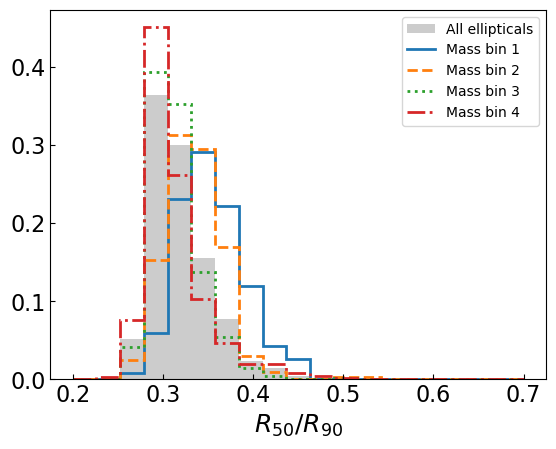

In [52]:
r50r90 = ellipticals['nsa_elpetro_th50_r']/ellipticals['nsa_elpetro_th90']
sfr_bins = np.linspace(0.2,0.7,20)
counts, bins = np.histogram(ellipticals['nsa_elpetro_th50_r']/ellipticals['nsa_elpetro_th90'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'All ellipticals')


counts, bins = np.histogram(bin1['nsa_elpetro_th50_r']/bin1['nsa_elpetro_th90'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'Mass bin 1', lw=2)

counts, bins = np.histogram(bin2['nsa_elpetro_th50_r']/bin2['nsa_elpetro_th90'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'Mass bin 2', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['nsa_elpetro_th50_r']/bin3['nsa_elpetro_th90'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'Mass bin 3', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['nsa_elpetro_th50_r']/bin4['nsa_elpetro_th90'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'Mass bin 4', linestyle='-.',lw=2)


plt.legend()

plt.xlabel(r'$R_{50}/R_{90}$', fontsize=18)
plt.tick_params(axis='both', direction='in', labelsize=16)

In [57]:
dist_to_galaxy_Mpc = c*ellipticals['nsa_z']/H_0
dist_to_galaxy_kpc = dist_to_galaxy_Mpc*1000

r50_kpc = dist_to_galaxy_kpc*np.tan(ellipticals['nsa_elpetro_th50_r']*(1./60)*(1./60)*(np.pi/180))
ellipticals['R50_kpc'] = r50_kpc

bins = np.linspace(9.3,11.9,5)
bin1 = ellipticals[ellipticals['sphd_M_star']+np.log10(0.73) < bins[1]]
bin2 = ellipticals[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) > bins[1], ellipticals['sphd_M_star']+np.log10(0.73) < bins[2])]
bin3 = ellipticals[np.logical_and(ellipticals['sphd_M_star']+np.log10(0.73) > bins[2], ellipticals['sphd_M_star']+np.log10(0.73) < bins[3])]
bin4 = ellipticals[ellipticals['sphd_M_star']+np.log10(0.73) > bins[3]]

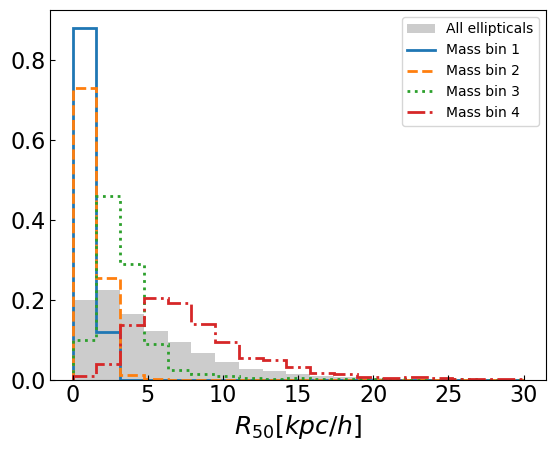

In [58]:
sfr_bins = np.linspace(0,30,20)
counts, bins = np.histogram(ellipticals['R50_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'All ellipticals')


counts, bins = np.histogram(bin1['R50_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'Mass bin 1', lw=2)

counts, bins = np.histogram(bin2['R50_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'Mass bin 2', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['R50_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'Mass bin 3', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['R50_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'Mass bin 4', linestyle='-.',lw=2)


plt.legend()

plt.xlabel(r'$R_{50} [kpc/h]$', fontsize=18)
plt.tick_params(axis='both', direction='in', labelsize=16)

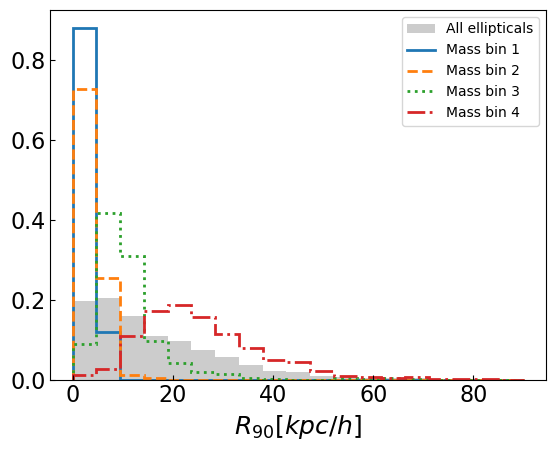

In [60]:
sfr_bins = np.linspace(0,90,20)
counts, bins = np.histogram(ellipticals['R90_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'All ellipticals')


counts, bins = np.histogram(bin1['R90_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'Mass bin 1', lw=2)

counts, bins = np.histogram(bin2['R90_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'Mass bin 2', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['R90_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'Mass bin 3', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['R90_kpc'], bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'Mass bin 4', linestyle='-.',lw=2)


plt.legend()

plt.xlabel(r'$R_{90} [kpc/h]$', fontsize=18)
plt.tick_params(axis='both', direction='in', labelsize=16)

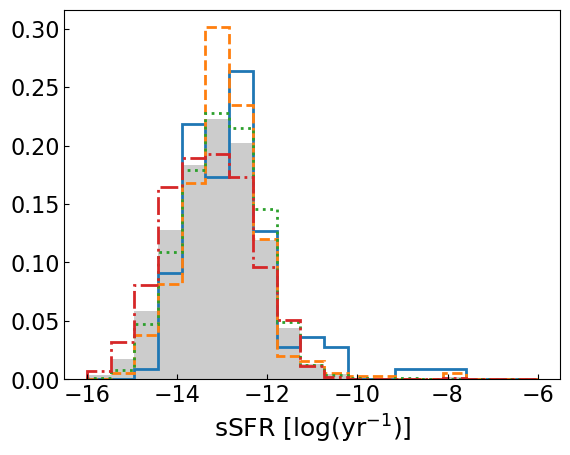

In [170]:
sfr_bins = np.linspace(-16,-6,20)

counts, bins = np.histogram(ellipticals['SFR'] - ellipticals['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['SFR']- bin1['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125', lw=2)

counts, bins = np.histogram(bin2['SFR'] - bin2['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['SFR'] - bin3['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['SFR'] - bin4['sphd_M_star']-np.log10(0.73), bins=sfr_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.',lw=2)


# plt.legend()

plt.xlabel(r'sSFR [$\log(\rm yr^{-1})$]', fontsize=18)
plt.tick_params(axis='both', direction='in', labelsize=16)

plt.savefig(plot_dir + 'Mtot_Mstar_bin_sSFR_hist_stacked.png', bbox_inches='tight')

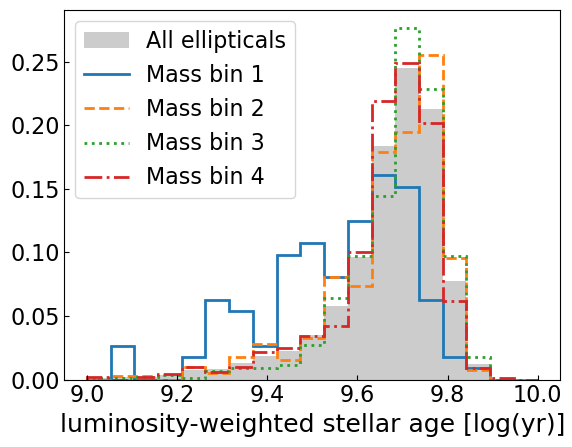

In [47]:
age_bins = np.linspace(9,10,20)

counts, bins = np.histogram(ellipticals['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'All ellipticals')


counts, bins = np.histogram(bin1['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'Mass bin 1', lw=2)

counts, bins = np.histogram(bin2['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'Mass bin 2', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'Mass bin 3', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['Age_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'Mass bin 4', linestyle='-.', lw=2)


plt.xlabel(r'luminosity-weighted stellar age [log(yr)]', fontsize=18)
plt.legend(fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=16)

plt.savefig(plot_dir + 'Mtot_Mstar_bin_LW_age_hist_stacked.png', bbox_inches='tight')

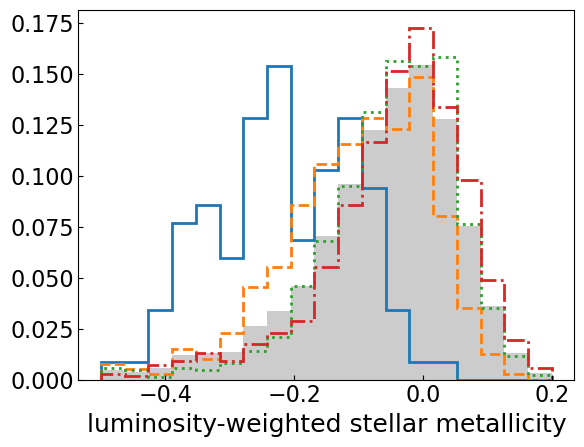

In [172]:
age_bins = np.linspace(-0.5,0.2,20)

counts, bins = np.histogram(ellipticals['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='k', fill=True, alpha=0.2, label=r'all ellipticals')


counts, bins = np.histogram(bin1['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:blue', label=r'$\log(M_{*,model}/M_\odot)$ < 10.125', lw=2)

counts, bins = np.histogram(bin2['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:orange', label=r'10.125 < $\log(M_{*,model}/M_\odot)$ < 10.75', linestyle='--', lw=2)

counts, bins = np.histogram(bin3['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:green', label=r'10.75 < $\log(M_{*,model}/M_\odot)$ < 11.375', linestyle=':', lw=2)

counts, bins = np.histogram(bin4['ZH_LW_Re_fit'], bins=age_bins)
plt.stairs(counts/np.sum(counts), bins, color='tab:red', label=r'$\log(M_{*,model}/M_\odot)$ > 11.375', linestyle='-.', lw=2)


plt.xlabel(r'luminosity-weighted stellar metallicity', fontsize=18)
# plt.legend()
plt.tick_params(axis='both', direction='in', labelsize=16)

plt.savefig(plot_dir + 'Mtot_Mstar_bin_LW_Z_hist_stacked.png', bbox_inches='tight')

(-100000000000.0, 1000000000000.0)

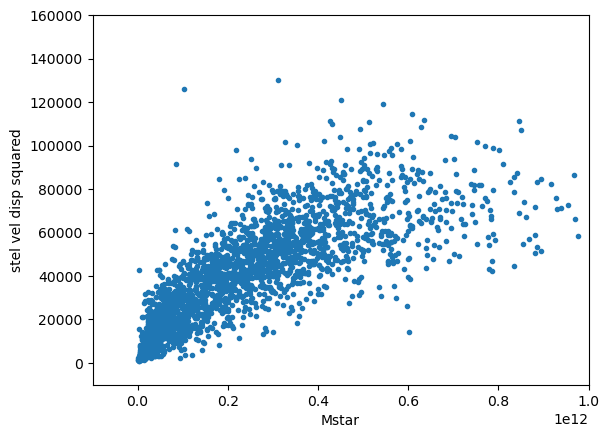

In [110]:
plt.scatter(10**ellipticals['sphd_M_star'], ellipticals['star_sigma']**2,marker='.', alpha=1)
plt.xlabel('Mstar')
plt.ylabel('stel vel disp squared')
plt.ylim(-10000, 160000)
plt.xlim(-10**11,10**12)

(9.0, 13.0)

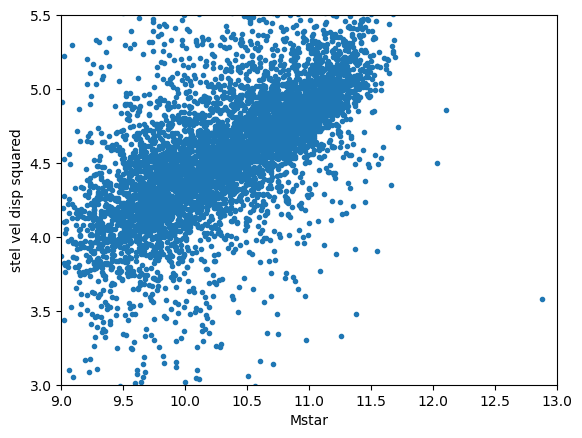

In [102]:
plt.scatter(spirals['M90_disk'],  np.log10(spirals['v_max']**2),marker='.', alpha=1)
plt.xlabel('Mstar')
plt.ylabel('stel vel disp squared')
plt.ylim(3, 5.5)
plt.xlim(9,13)

(9.0, 12.5)

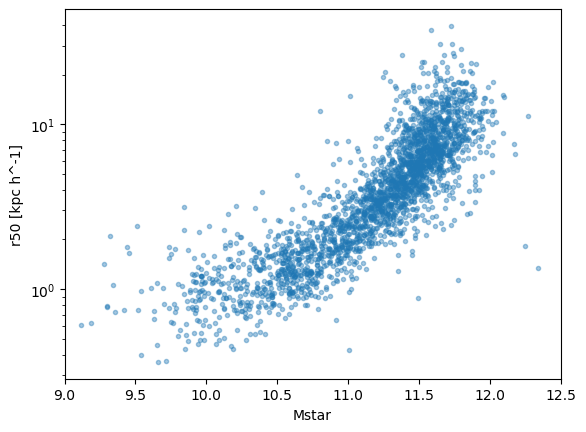

In [71]:
plt.semilogy(ellipticals['sphd_M_star'], ellipticals['R50_kpc'], '.', alpha=0.4)
plt.xlabel('Mstar')
plt.ylabel('r50 [kpc h^-1]')
plt.xlim(9,12.5)
# plt.ylim(0,100000)


### parametric mtot vs mstar

In [178]:
def parametric_mtot_mstar(m1, b1, m2, b2):

    m = m1/m2
    b = b1 - (m1/m2)*b2

    return m, b

In [179]:
m_e_all, b_e_all = parametric_mtot_mstar(popt5[0], popt5[1], popt1[0], popt1[1])
m_e_lim, b_e_lim = parametric_mtot_mstar(popt6[0], popt6[1], popt2[0], popt2[1])
m_bs_all, b_bs_all = parametric_mtot_mstar(popt7[0], popt7[1], popt3[0], popt3[1])
m_bs_lim, b_bs_lim = parametric_mtot_mstar(popt8[0], popt8[1], popt4[0], popt4[1])

In [184]:
bins = np.linspace(8.8,
                  11.8, 15)
pts = (bins[:-1] + bins [1:]) / 2


e_mtot = []
s_mtot = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mtot.append(ellipticals['Mvir'][ellipticals['e_Mstar_R90']+np.log10(0.73) <= mag_lim])
        s_mtot.append(blue_spirals['M_R90'][blue_spirals['M90_disk']+np.log10(0.73) <= mag_lim])
        
    else:
        lower_lim = bins[i]
        e_mtot.append(ellipticals['Mvir'][np.logical_and(ellipticals['e_Mstar_R90']+np.log10(0.73) <= mag_lim, 
                                                                         ellipticals['e_Mstar_R90']+np.log10(0.73) > lower_lim)])
        
        s_mtot .append(blue_spirals['M_R90'][np.logical_and(blue_spirals['M90_disk']+np.log10(0.73)<= mag_lim, 
                                                            blue_spirals['M90_disk']+np.log10(0.73) > lower_lim)])


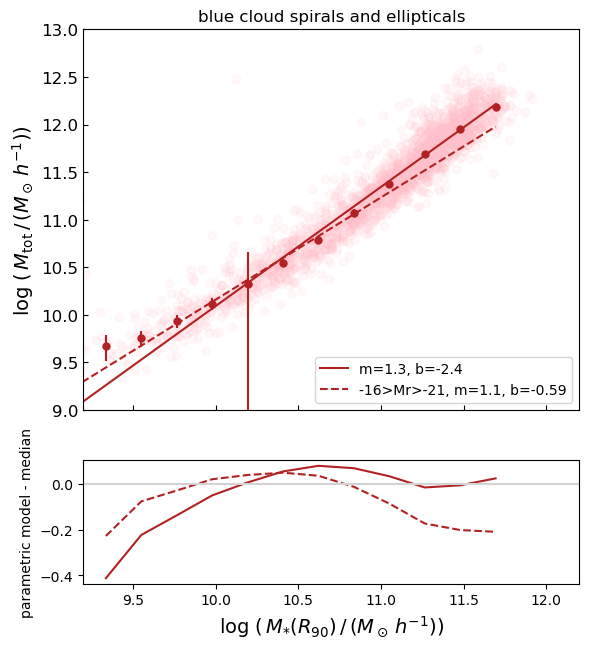

In [203]:
fig, ax = plt.subplots(2,1,sharex=True, height_ratios=(4,1.3), figsize=(6.4,7.2))

ax[0].scatter(ellipticals['e_Mstar_R90']+np.log10(0.73), ellipticals['Mvir'], color='pink', alpha=0.1, )
# ax[0].scatter(blue_spirals['M90_disk']+np.log10(0.73), blue_spirals['M_R90'], 
#             color='cornflowerblue', alpha=0.2, marker='+', )


ax[1].set_xlabel(r'$\log\,(\,M_{*}(R_{90})\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[0].set_xlim(9.2,12.2)
ax[0].set_ylim(9,13)
ax[0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
ax[0].tick_params( axis='both', direction='in',labelsize=12)
# ax[0].plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)
ax[0].set_title('blue cloud spirals and ellipticals')

ep_mstar = med_err(e_mtot)
inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]

ax[0].errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o',linestyle='none', markersize=5, )
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9, 
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
                linestyle='none', color='firebrick', mfc='none', mec='none')
ax[0].plot(pts, pts*m_e_all + b_e_all, color='firebrick', label=f'm={m_e_all:.{2}}, b={b_e_all:.{2}}')
ax[1].plot(pts, pts*m_e_all + b_e_all - ep_mstar[:,0], color='firebrick')

ax[0].plot(pts, pts*m_e_lim + b_e_lim, color='firebrick', linestyle='--',  label=f'-16>Mr>-21, m={m_e_lim:.{2}}, b={b_e_lim:.{2}}')
ax[1].plot(pts, pts*m_e_lim + b_e_lim - ep_mstar[:,0], color='firebrick', linestyle='--')



# ep_mstar = med_err(s_mtot)
# inf_bars = np.where(ep_mstar == np.inf)[0]
# ep_mstar[inf_bars][:,0]

# ax[0].errorbar(pts, ep_mstar[:,0], color='navy', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
#              marker='x', linestyle='none', markersize=5, )
# ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
#              yerr=ep_mstar[inf_bars][:,0]-9, 
#              uplims=True,
#              color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
# ax[0].errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
#                 linestyle='none', color='navy', mfc='none', mec='none')




# ax[0].plot(pts, pts*m_bs_all + b_bs_all, color='navy',  label=f'm={m_bs_all:.{2}}, b={b_bs_all:.{2}}')
# ax[1].plot(pts, pts*m_bs_all + b_bs_all - ep_mstar[:,0], color='navy')


# ax[0].plot(pts, pts*m_bs_lim + b_bs_lim, color='navy', linestyle='--', label=f'-16>Mr>-21, m={m_bs_lim:.{2}}, b={b_bs_lim:.{2}}')
# ax[1].plot(pts, pts*m_bs_lim + b_bs_lim - ep_mstar[:,0], color='navy', linestyle='--')

ax[1].axhline(0, color='lightgrey')
ax[0].legend()

ax[1].set_ylabel('parametric model - median')

plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_spirals_median_parametric_linfit.png')